In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/data/data_clinical_patient.txt

/content/drive/MyDrive/data/data_clinical_patient.txt


# METABRIC Dataset Exploration and Preprocessing

This notebook loads and explores the clinical data from the METABRIC breast cancer dataset.
Key steps:
- Load clinical sample data
- Analyze target variable distribution
- Check for missing values
- Explore feature distributions
- Initial data cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('default')
sns.set_palette('husl')

# Set random seed
np.random.seed(42)

# Data directory
data_dir = Path('/content/drive/MyDrive/data')
results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)

print(f'Current working directory: {Path.cwd()}')
print(f'Data directory: {data_dir.resolve()}')
print('Data files in data directory:', list(data_dir.glob('data_*.txt')))

Current working directory: /content
Data directory: /content/drive/MyDrive/data
Data files in data directory: [PosixPath('/content/drive/MyDrive/data/data_mutations.txt'), PosixPath('/content/drive/MyDrive/data/data_cna.txt'), PosixPath('/content/drive/MyDrive/data/data_methylation_promoters_rrbs.txt'), PosixPath('/content/drive/MyDrive/data/data_clinical_sample.txt'), PosixPath('/content/drive/MyDrive/data/data_gene_panel_matrix.txt'), PosixPath('/content/drive/MyDrive/data/data_clinical_patient.txt'), PosixPath('/content/drive/MyDrive/data/data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt'), PosixPath('/content/drive/MyDrive/data/data_mrna_illumina_microarray.txt')]


In [ ]:
# Load clinical sample data
clinical_df = pd.read_csv(data_dir / 'data_clinical_sample.txt', sep='\t', low_memory=False)
print(f'Clinical data shape: {clinical_df.shape}')
print('Columns:', list(clinical_df.columns))
print('\nFirst 5 rows:')
clinical_df.head()

Clinical data shape: (2513, 13)
Columns: ['#Patient Identifier', 'Sample Identifier', 'Cancer Type', 'Cancer Type Detailed', 'ER Status', 'HER2 Status', 'Neoplasm Histologic Grade', 'Oncotree Code', 'PR Status', 'Sample Type', 'Tumor Size', 'Tumor Stage', 'TMB (nonsynonymous)']

First 5 rows:


,#Patient Identifier,Sample Identifier,Cancer Type,Cancer Type Detailed,ER Status,HER2 Status,Neoplasm Histologic Grade,Oncotree Code,PR Status,Sample Type,Tumor Size,Tumor Stage,TMB (nonsynonymous)
0,#Identifier to uniquely specify a patient.,A unique sample identifier.,Cancer Type,Cancer Type Detailed,ER Status,HER2 Status,Numeric value to express the degree of abnorma...,Oncotree Code,PR Status,"The type of sample (i.e., normal, primary, met...",Tumor size.,Tumor stage.,TMB (nonsynonymous)
1,#STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,NUMBER
2,#1,1,1,1,1,1,1,1,1,1,1,1,1
3,PATIENT_ID,SAMPLE_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,ER_STATUS,HER2_STATUS,GRADE,ONCOTREE_CODE,PR_STATUS,SAMPLE_TYPE,TUMOR_SIZE,TUMOR_STAGE,TMB_NONSYNONYMOUS
4,MB-0000,MB-0000,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3,IDC,Negative,Primary,22,2,0


In [ ]:
# Get data types and basic info
print('Data info:')
clinical_df.info()

print('\nColumn names:')
for i, col in enumerate(clinical_df.columns):
    print('2d')

# Check for duplicate columns
print(f'\nNumber of duplicated columns: {clinical_df.columns.duplicated().sum()}')
if clinical_df.columns.duplicated().any():
    print('Duplicate columns:', clinical_df.columns[clinical_df.columns.duplicated()])

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   #Patient Identifier        2513 non-null   object
 1   Sample Identifier          2513 non-null   object
 2   Cancer Type                2513 non-null   object
 3   Cancer Type Detailed       2513 non-null   object
 4   ER Status                  2473 non-null   object
 5   HER2 Status                1984 non-null   object
 6   Neoplasm Histologic Grade  2392 non-null   object
 7   Oncotree Code              2513 non-null   object
 8   PR Status                  1984 non-null   object
 9   Sample Type                2513 non-null   object
 10  Tumor Size                 2364 non-null   object
 11  Tumor Stage                1792 non-null   object
 12  TMB (nonsynonymous)        2513 non-null   object
dtypes: object(13)
memory usage: 255.4+ KB

Column names:

In [ ]:
# Analyze target variable distribution
target_col = 'Cancer Type Detailed'
print(f'\nTarget variable: {target_col}')
print(f'Number of unique classes: {clinical_df[target_col].nunique()}')
print(f'\nValue counts (top 10):')
clinical_df[target_col].value_counts().head(10)


Target variable: Cancer Type Detailed
Number of unique classes: 12

Value counts (top 10):


,count
Cancer Type Detailed,
Breast Invasive Ductal Carcinoma,1865
Breast Mixed Ductal and Lobular Carcinoma,269
Breast Invasive Lobular Carcinoma,192
Invasive Breast Carcinoma,133
Breast Invasive Mixed Mucinous Carcinoma,25
Breast,21
Breast Angiosarcoma,2
Metaplastic Breast Cancer,2
CANCER_TYPE_DETAILED,1


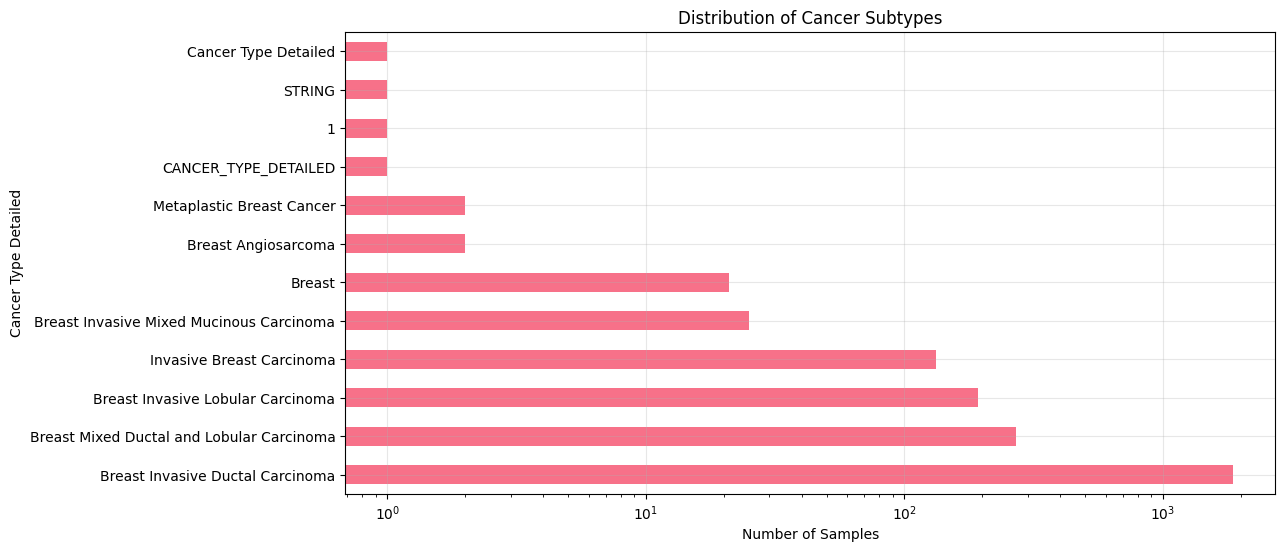


Subtype percentages:


,count
Cancer Type Detailed,
Breast Invasive Ductal Carcinoma,74.21
Breast Mixed Ductal and Lobular Carcinoma,10.70
Breast Invasive Lobular Carcinoma,7.64
Invasive Breast Carcinoma,5.29
Breast Invasive Mixed Mucinous Carcinoma,0.99
Breast,0.84
Breast Angiosarcoma,0.08
Metaplastic Breast Cancer,0.08
CANCER_TYPE_DETAILED,0.04


In [ ]:
# Plot target variable distribution
plt.figure(figsize=(12, 6))
ax = clinical_df[target_col].value_counts().plot(kind='barh')
plt.title('Distribution of Cancer Subtypes')
plt.xlabel('Number of Samples')
plt.ylabel('Cancer Type Detailed')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.savefig(results_dir / 'cancer_subtype_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print percentages
subtype_percentages = (clinical_df[target_col].value_counts() / len(clinical_df) * 100).round(2)
print('\nSubtype percentages:')
subtype_percentages.head(10)

In [ ]:
# Check for missing values
missing_data = clinical_df.isnull().sum()
missing_percent = (missing_data / len(clinical_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

print('Missing values summary:')
missing_summary[missing_summary['Missing Count'] > 0]

Missing values summary:


,Missing Count,Missing Percent
Tumor Stage,721,28.69
HER2 Status,529,21.05
PR Status,529,21.05
Tumor Size,149,5.93
Neoplasm Histologic Grade,121,4.81
ER Status,40,1.59


/tmp/ipython-input-3097118332.py:28: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


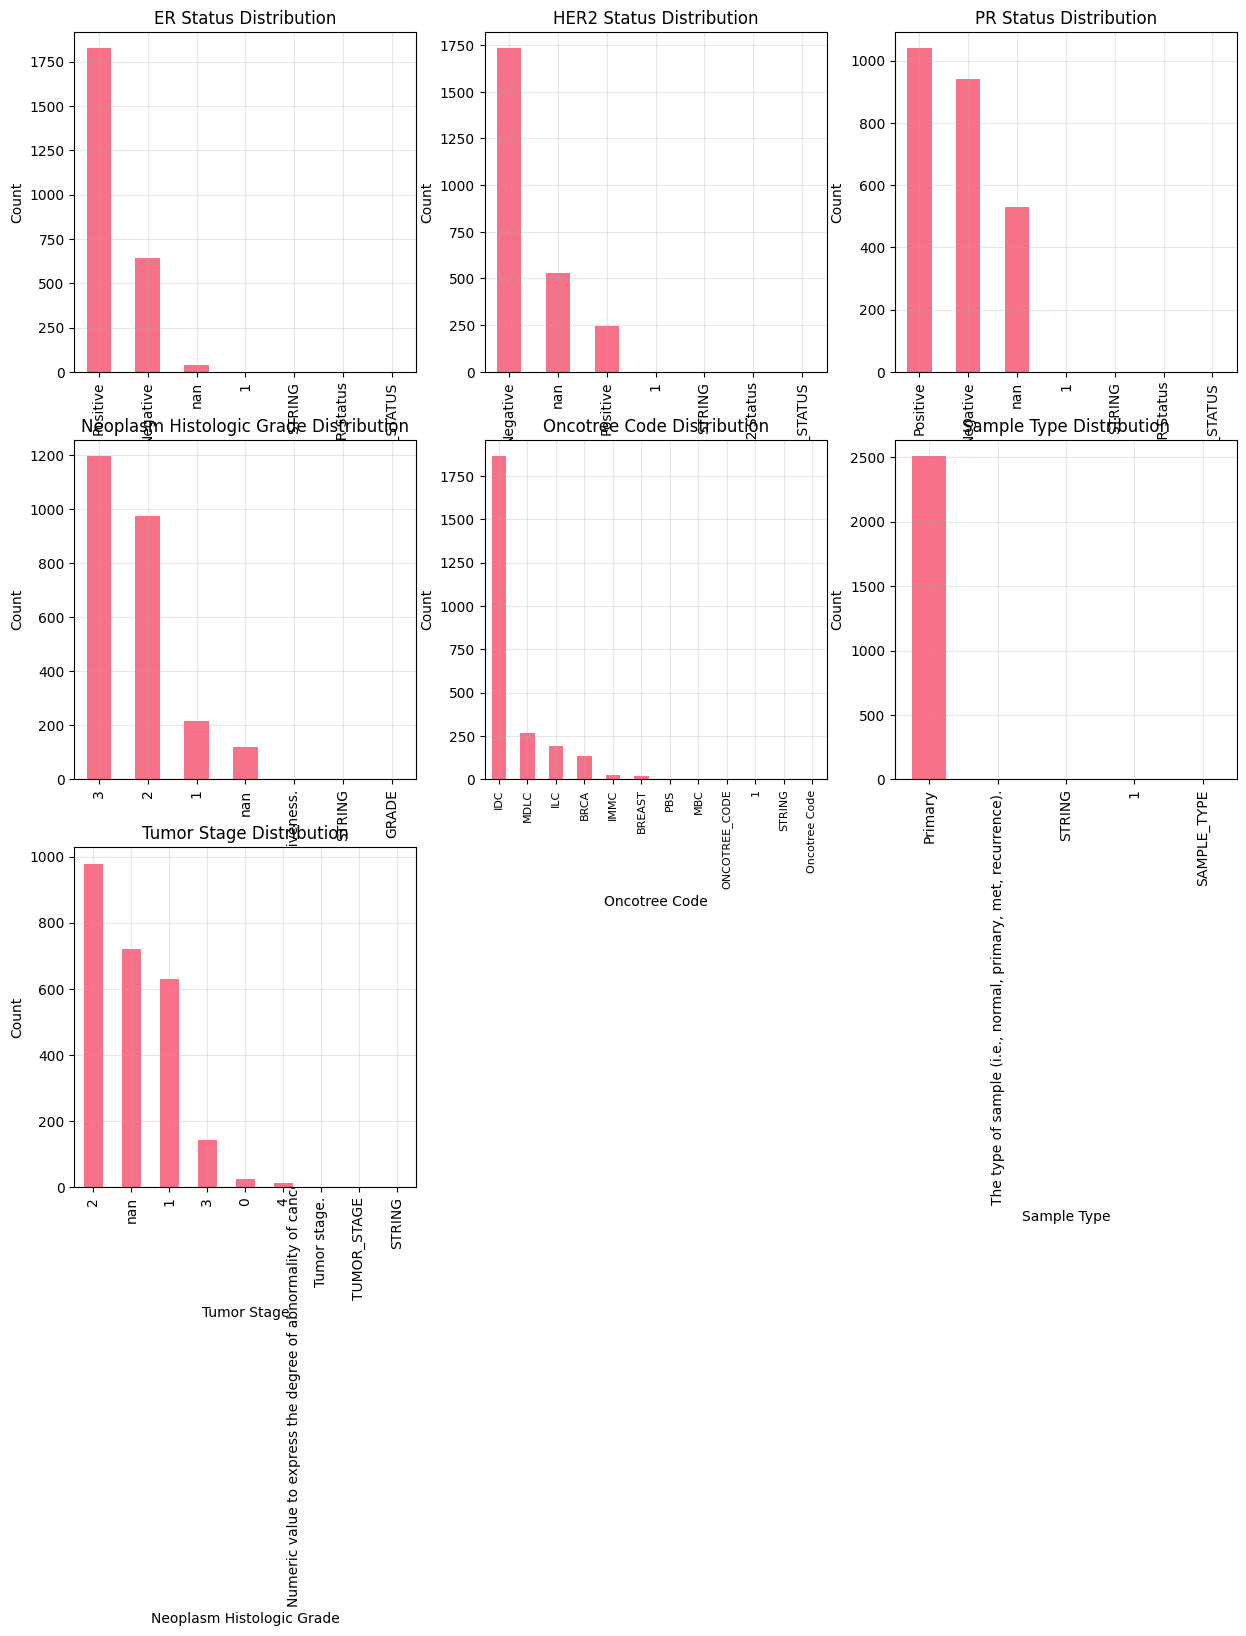

In [ ]:
# Analyze categorical features
categorical_cols = ['ER Status', 'HER2 Status', 'PR Status', 'Neoplasm Histologic Grade', 'Oncotree Code', 'Sample Type', 'Tumor Stage']

# Create subplots in a grid
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        value_counts = clinical_df[col].value_counts(dropna=False)

        # Handle long category names by rotating labels
        if len(value_counts) > 10:
            axes[i].tick_params(axis='x', rotation=45, labelsize=8)

        value_counts.plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'{col} Distribution')
        axes[i].set_ylabel('Count')
        axes[i].grid(True, alpha=0.3)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(results_dir / 'categorical_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

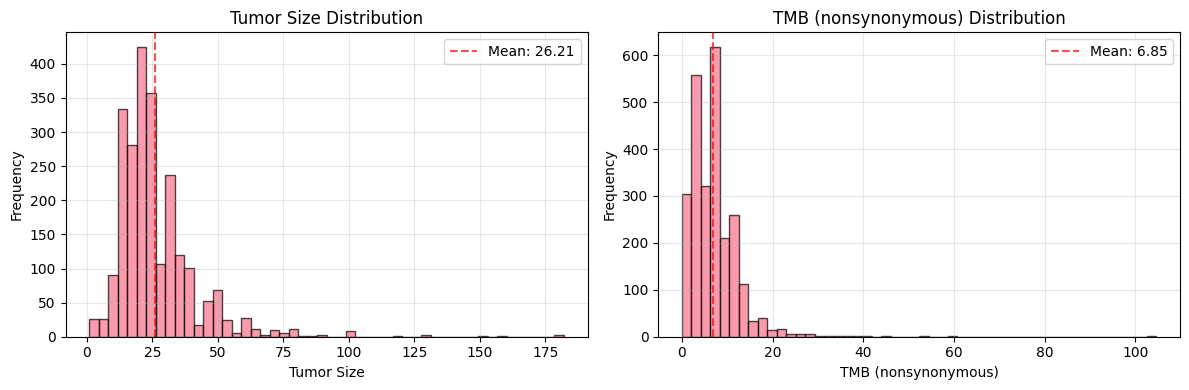

Numeric features summary:

Tumor Size:
  Mean: 26.21
  Median: 22.32
  Std: 15.38
  Min: 1.00
  Max: 182.00
  Missing: 152 (6.0%)

TMB (nonsynonymous):
  Mean: 6.85
  Median: 6.54
  Std: 5.32
  Min: 0.00
  Max: 104.60
  Missing: 3 (0.1%)


In [ ]:
# Analyze numeric features
numeric_cols = ['Tumor Size', 'TMB (nonsynonymous)']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(12, 4))
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    # Convert to numeric, handling NaN
    numeric_data = pd.to_numeric(clinical_df[col], errors='coerce')

    # Plot histogram for non-null values
    axes[i].hist(numeric_data.dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(numeric_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {numeric_data.mean():.2f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'numeric_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print('Numeric features summary:')
for col in numeric_cols:
    numeric_data = pd.to_numeric(clinical_df[col], errors='coerce')
    print(f'\n{col}:')
    print(f'  Mean: {numeric_data.mean():.2f}')
    print(f'  Median: {numeric_data.median():.2f}')
    print(f'  Std: {numeric_data.std():.2f}')
    print(f'  Min: {numeric_data.min():.2f}')
    print(f'  Max: {numeric_data.max():.2f}')
    print(f'  Missing: {numeric_data.isnull().sum()} ({numeric_data.isnull().sum() / len(numeric_data) * 100:.1f}%)')


ER Status vs Top Cancer Types:
ER Status                                  Negative  Positive
Cancer Type Detailed                                         
Breast Invasive Ductal Carcinoma               0.29      0.71
Breast Invasive Lobular Carcinoma              0.16      0.84
Breast Invasive Mixed Mucinous Carcinoma       0.04      0.96
Breast Mixed Ductal and Lobular Carcinoma      0.11      0.89
Invasive Breast Carcinoma                      0.37      0.63

HER2 Status vs Top Cancer Types:
HER2 Status                                Negative  Positive
Cancer Type Detailed                                         
Breast Invasive Ductal Carcinoma               0.86      0.14
Breast Invasive Lobular Carcinoma              0.94      0.06
Breast Invasive Mixed Mucinous Carcinoma       0.91      0.09
Breast Mixed Ductal and Lobular Carcinoma      0.97      0.03
Invasive Breast Carcinoma                      0.76      0.24


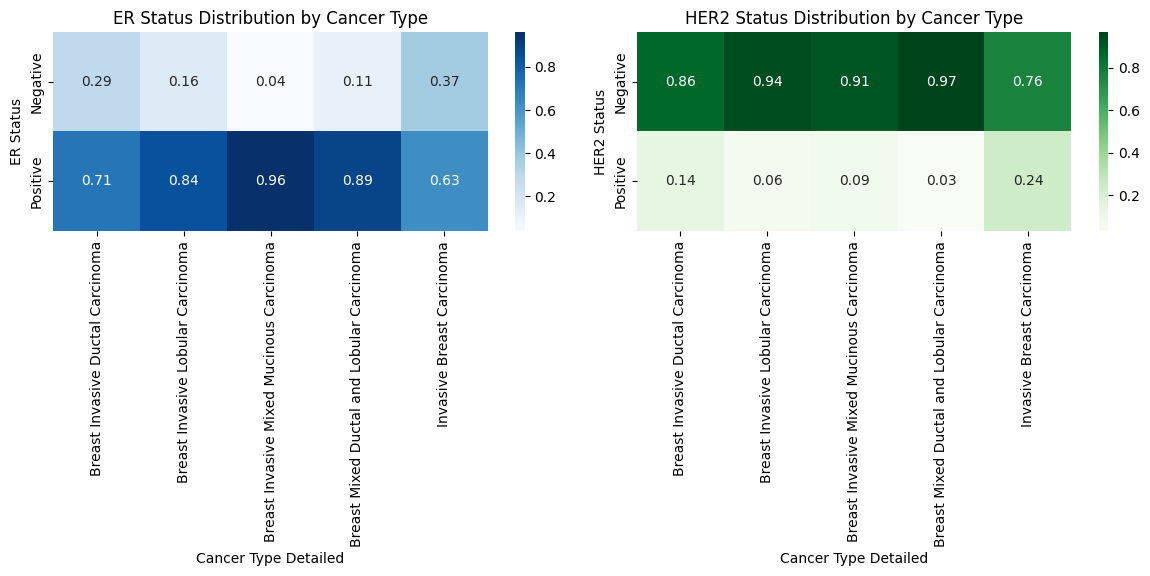

In [ ]:
# Check target variable vs clinical features
# Focus on major subtypes (top 5)
top_subtypes = clinical_df[target_col].value_counts().nlargest(5).index
major_clinical = clinical_df[clinical_df[target_col].isin(top_subtypes)]

# Create cross-tabulations
print('\nER Status vs Top Cancer Types:')
er_crosstab = pd.crosstab(major_clinical[target_col], major_clinical['ER Status'], normalize='index')
print(er_crosstab.round(2))

print('\nHER2 Status vs Top Cancer Types:')
her2_crosstab = pd.crosstab(major_clinical[target_col], major_clinical['HER2 Status'], normalize='index')
print(her2_crosstab.round(2))

# Plot correlations
plt.figure(figsize=(12, 8))

# ER status by subtype
plt.subplot(2, 2, 1)
sns.heatmap(er_crosstab.T, annot=True, cmap='Blues', cbar=True, fmt='.2f')
plt.title('ER Status Distribution by Cancer Type')
plt.ylabel('ER Status')

# HER2 status by subtype
plt.subplot(2, 2, 2)
sns.heatmap(her2_crosstab.T, annot=True, cmap='Greens', cbar=True, fmt='.2f')
plt.title('HER2 Status Distribution by Cancer Type')
plt.ylabel('HER2 Status')

plt.tight_layout()
plt.savefig(results_dir / 'clinical_features_vs_subtypes.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Save cleaned clinical data
print('Saving clinical data...')
clinical_df.to_pickle(results_dir / 'clinical_data_explored.pkl')
clinical_df.to_csv(results_dir / 'clinical_data_explored.csv', index=False)

# Summary of findings
print('\n=== DATA EXPLORATION SUMMARY ===')
print(f'1. Dataset shape: {clinical_df.shape}')
print(f'2. Target classes: {clinical_df[target_col].nunique()}')
print(f'3. Most common subtype: {clinical_df[target_col].mode()[0]} ({clinical_df[target_col].value_counts().iloc[0]} samples)')
print(f'4. Most rare subtypes have {clinical_df[target_col].value_counts().min()} samples')
print(f'5. Missing data columns: {missing_summary[missing_summary["Missing Count"] > 0].shape[0]}')
print(f'   Most missing feature: {missing_summary.index[0]} ({missing_summary.iloc[0,1]:.1f}%)')
print('6. Key clinical features encoded categorically')
print('7. Numeric features need scaling (TUMOR_SIZE, TMB)')
print('8. Class imbalance present - will need stratified sampling')

Saving clinical data...

=== DATA EXPLORATION SUMMARY ===
1. Dataset shape: (2513, 13)
2. Target classes: 12
3. Most common subtype: Breast Invasive Ductal Carcinoma (1865 samples)
4. Most rare subtypes have 1 samples
5. Missing data columns: 6
   Most missing feature: Tumor Stage (28.7%)
6. Key clinical features encoded categorically
7. Numeric features need scaling (TUMOR_SIZE, TMB)
8. Class imbalance present - will need stratified sampling


## Identify remaining files



In [ ]:
# List all files in the data directory
all_files = list(data_dir.glob('data_*.txt'))
print("All files in the data directory:")
for file in all_files:
    print(file.name)

# Files already explored (data_clinical_sample.txt has been loaded)
explored_files = ['data_clinical_sample.txt']

# Create a list of files to be explored
remaining_files = [file.name for file in all_files if file.name not in explored_files]

print("\nRemaining files to be explored:")
for file_name in remaining_files:
    print(file_name)

All files in the data directory:
data_mutations.txt
data_cna.txt
data_methylation_promoters_rrbs.txt
data_clinical_sample.txt
data_gene_panel_matrix.txt
data_clinical_patient.txt
data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt
data_mrna_illumina_microarray.txt

Remaining files to be explored:
data_mutations.txt
data_cna.txt
data_methylation_promoters_rrbs.txt
data_gene_panel_matrix.txt
data_clinical_patient.txt
data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt
data_mrna_illumina_microarray.txt



##Load the first remaining data file, display its shape, columns, data types, and the first few rows to get an initial overview of the data structure and content.


In [ ]:
# Get the first remaining file name
current_file = remaining_files.pop(0)
print(f'Loading file: {current_file}')

# Construct the full path
file_path = data_dir / current_file

# Read the data file into a pandas DataFrame
# Assuming the separator is space(s) based on previous file analysis, and low_memory=False for large files
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Print shape, columns, and data types
print(f'\nShape: {df.shape}')
print('\nColumns:')
print(df.columns.tolist())
print('\nData types and info:')
df.info()

# Display the first few rows
print('\nFirst 5 rows:')
display(df.head())

In [ ]:
# Reload the data skipping the initial metadata rows and specifying the correct header
file_path = data_dir / current_file
df = pd.read_csv(file_path, sep='\t', skiprows=3, low_memory=False)

# Print shape, columns, and data types of the reloaded DataFrame
print(f'\nShape after skipping header rows: {df.shape}')
print('\nColumns after skipping header rows:')
print(df.columns.tolist())
print('\nData types and info after skipping header rows:')
df.info()

# Display the first few rows of the reloaded DataFrame
print('\nFirst 5 rows after skipping header rows:')
display(df.head())


Shape after skipping header rows: (17270, 45)

Columns after skipping header rows:
['TP53', 'Unnamed: 1', 'METABRIC', 'GRCh37', '17', '7579346', '7579347', '+', 'protein_altering_variant', 'In_Frame_Ins', 'INS', '-', '-.1', 'CAG', 'Unnamed: 14', 'Unnamed: 15', 'MTS-T0058', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Illumina HiSeq 2,000', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'ENST00000269305.4:c.340_341insCTG', 'p.Leu114delinsSerVal', 'p.L114delinsSV', 'ENST00000269305', 'NM_001126112.2', '114', 'ttg/tCTGtg', '0']

Data types and info after skipping header rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17270 entries, 0 to 17269
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             ------------

,TP53,Unnamed: 1,METABRIC,GRCh37,17,7579346,7579347,+,protein_altering_variant,In_Frame_Ins,...,Unnamed: 35,Unnamed: 36,ENST00000269305.4:c.340_341insCTG,p.Leu114delinsSerVal,p.L114delinsSV,ENST00000269305,NM_001126112.2,114,ttg/tCTGtg,0
0,MLLT4,NaN,METABRIC,GRCh37,6,168299111,168299111,+,missense_variant,Missense_Mutation,...,NaN,NaN,ENST00000392108.3:c.1544G>T,p.Gly515Val,p.G515V,ENST00000392108,NM_001040000.2,515.0,gGa/gTa,0
1,NF2,NaN,METABRIC,GRCh37,22,29999995,29999995,+,missense_variant,Missense_Mutation,...,NaN,NaN,ENST00000338641.4:c.8G>T,p.Gly3Val,p.G3V,ENST00000338641,NM_000268.3,3.0,gGg/gTg,0
2,SF3B1,NaN,METABRIC,GRCh37,2,198288682,198288682,+,synonymous_variant,Silent,...,NaN,NaN,ENST00000335508.6:c.45T>A,p.Ile15=,p.I15=,ENST00000335508,NM_012433.2,15.0,atT/atA,0
3,NT5E,NaN,METABRIC,GRCh37,6,86195125,86195125,+,synonymous_variant,Silent,...,NaN,NaN,ENST00000257770.3:c.924T>C,p.Ile308=,p.I308=,ENST00000257770,NM_002526.3,308.0,atT/atC,0
4,EGFR,NaN,METABRIC,GRCh37,7,55241717,55241717,+,missense_variant,Missense_Mutation,...,NaN,NaN,ENST00000275493.2:c.2165C>T,p.Ala722Val,p.A722V,ENST00000275493,NM_005228.3,722.0,gCg/gTg,0


In [ ]:
# Generate descriptive statistics for numerical columns
print('Descriptive statistics for numerical columns:')
display(df.describe())

# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df) * 100).round(2)

# Create a summary DataFrame for missing values
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

# Print the missing values summary (only columns with missing values)
print('\nMissing values summary:')
display(missing_summary[missing_summary['Missing Count'] > 0])

Descriptive statistics for numerical columns:


,Unnamed: 1,7579346,7579347,Unnamed: 14,Unnamed: 15,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,...,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,114,0
count,0.0,1.727000e+04,1.727000e+04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16866.000000,17270.0
mean,NaN,8.314473e+07,8.314473e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1433.282225,0.0
std,NaN,6.434440e+07,6.434440e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1728.966815,0.0
min,NaN,1.932270e+05,1.932270e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0
25%,NaN,2.844369e+07,2.844369e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,323.000000,0.0
50%,NaN,6.534192e+07,6.534192e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,846.000000,0.0
75%,NaN,1.394028e+08,1.394028e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1848.500000,0.0
max,NaN,2.383037e+08,2.383037e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11980.000000,0.0



Missing values summary:


,Missing Count,Missing Percent
Unnamed: 1,17270,100.00
Unnamed: 24,17270,100.00
Unnamed: 23,17270,100.00
Unnamed: 26,17270,100.00
Unnamed: 25,17270,100.00
Unnamed: 21,17270,100.00
Unnamed: 22,17270,100.00
Unnamed: 20,17270,100.00
Unnamed: 19,17270,100.00
Unnamed: 17,17270,100.00


Data types of each column:
TP53                                  object
Unnamed: 1                           float64
METABRIC                              object
GRCh37                                object
17                                    object
7579346                                int64
7579347                                int64
+                                     object
protein_altering_variant              object
In_Frame_Ins                          object
INS                                   object
-                                     object
-.1                                   object
CAG                                   object
Unnamed: 14                          float64
Unnamed: 15                          float64
MTS-T0058                             object
Unnamed: 17                          float64
Unnamed: 18                          float64
Unnamed: 19                          float64
Unnamed: 20                          float64
Unnamed: 21                 

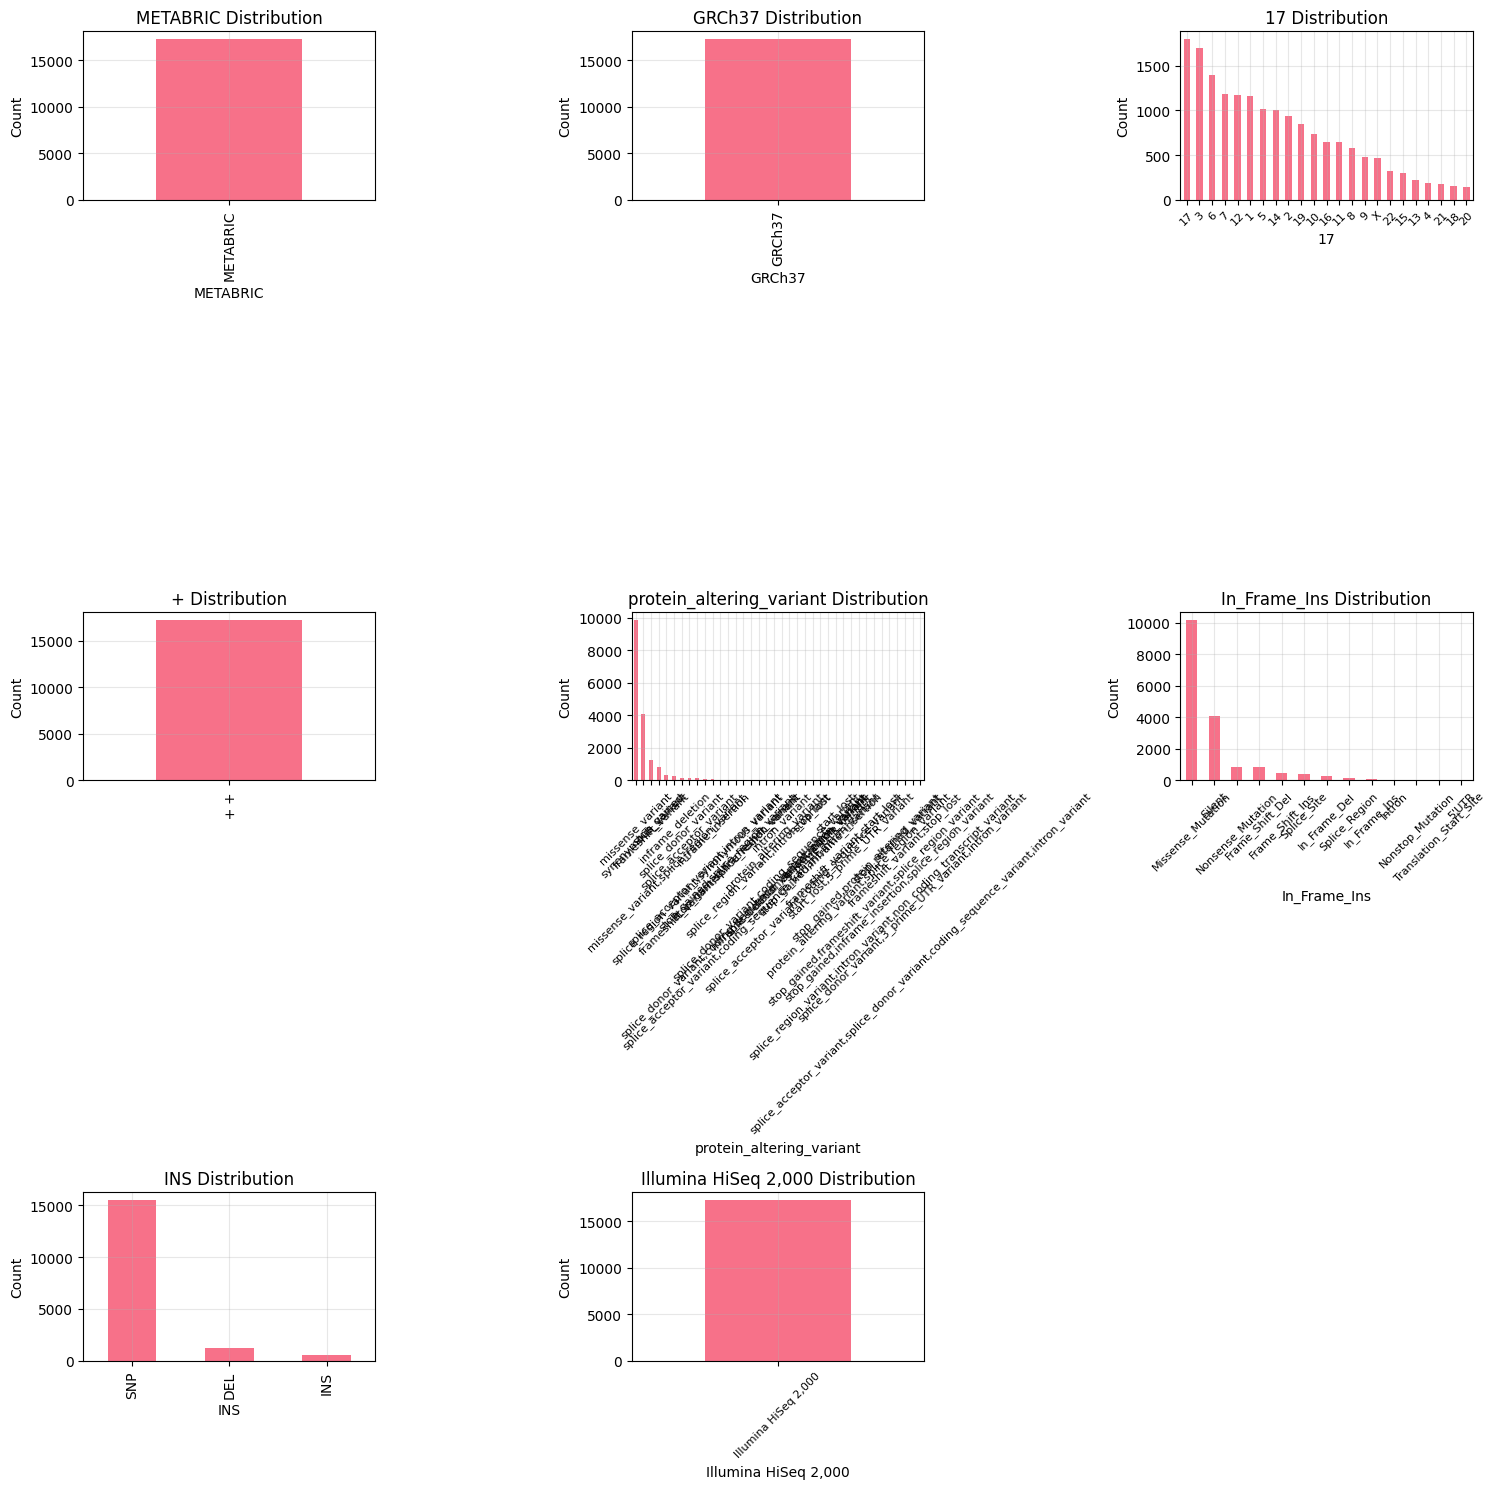

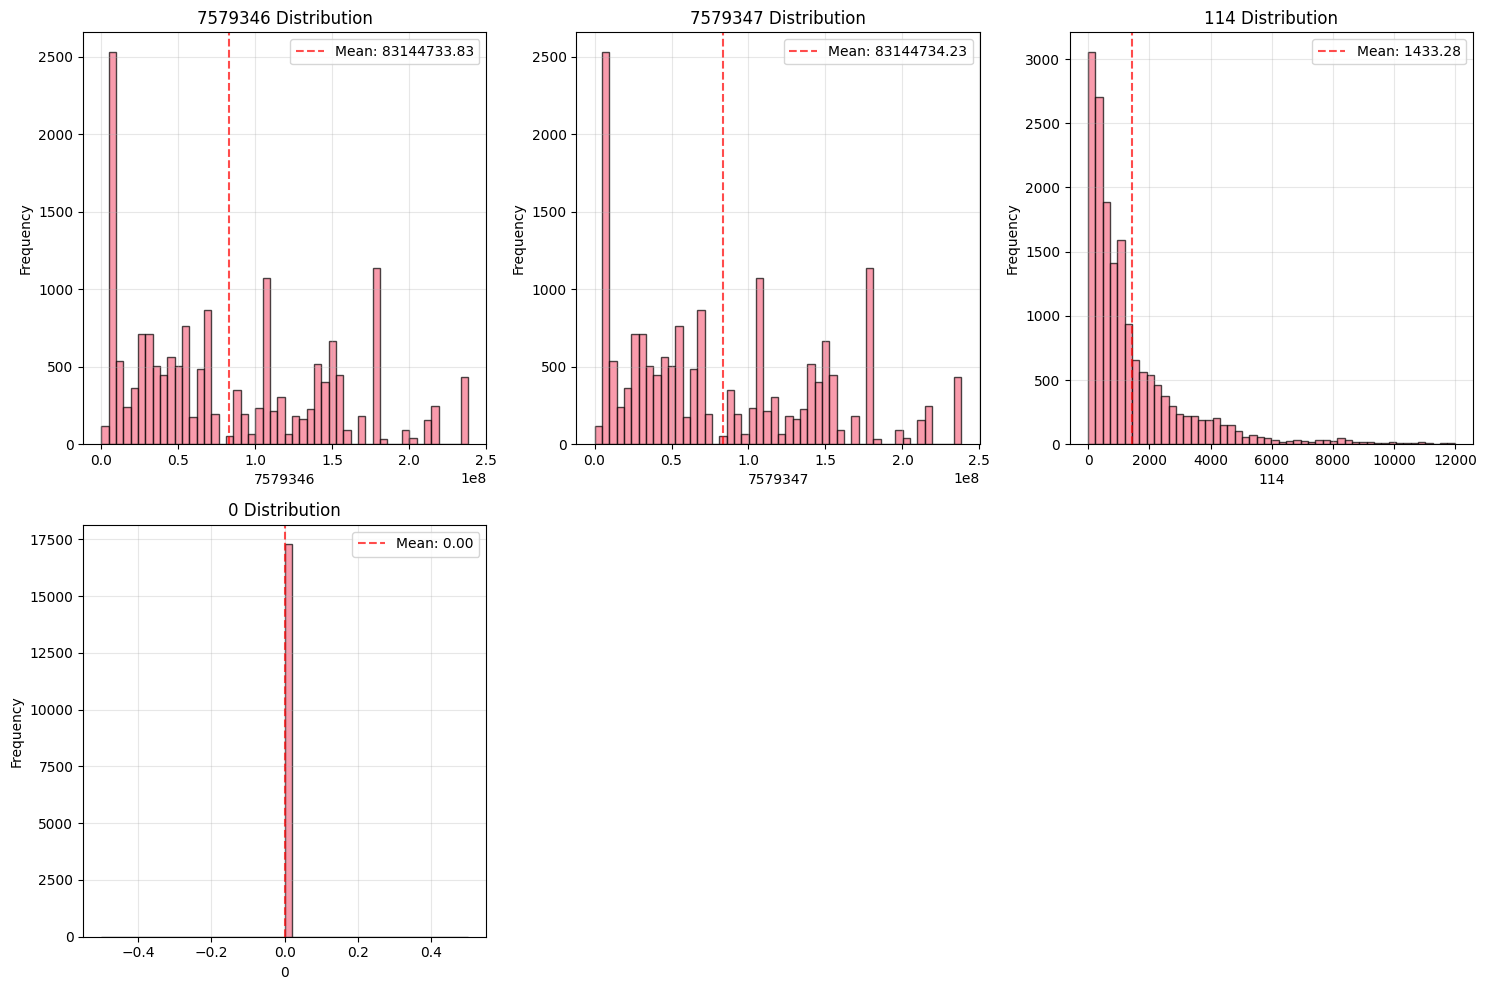

In [ ]:
# 1. Print the data types of each column
print('Data types of each column:')
print(df.dtypes)

# 2. Identify columns suitable for visualization
# Categorical columns: Object type, exclude columns with too many unique values or all NaNs
# Numerical columns: int or float type

categorical_cols = []
numerical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        # Check number of unique values and non-null count
        if df[col].nunique() < 50 and df[col].count() > 0: # Threshold for unique values can be adjusted
             categorical_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Check non-null count
        if df[col].count() > 0:
            numerical_cols.append(col)

print(f'\nIdentified categorical columns for visualization: {categorical_cols}')
print(f'Identified numerical columns for visualization: {numerical_cols}')


# 3. Visualize suitable categorical columns
if categorical_cols:
    n_cols = 3
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            try:
                value_counts = df[col].value_counts(dropna=False)
                value_counts.plot(kind='bar', ax=axes[i])
                axes[i].set_title(f'{col} Distribution')
                axes[i].set_ylabel('Count')
                axes[i].grid(True, alpha=0.3)
                # Rotate labels if needed
                if len(value_counts) > 5 or value_counts.index.astype(str).str.len().max() > 10:
                     axes[i].tick_params(axis='x', rotation=45, labelsize=8)
            except Exception as e:
                print(f"Could not plot categorical column {col}: {e}")


    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(results_dir / 'mutation_categorical_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable categorical columns found for visualization.")

# 4. Visualize suitable numerical columns
if numerical_cols:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if len(numerical_cols) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        if i < len(axes):
            try:
                numeric_data = pd.to_numeric(df[col], errors='coerce')
                axes[i].hist(numeric_data.dropna(), bins=50, alpha=0.7, edgecolor='black')
                axes[i].set_title(f'{col} Distribution')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Frequency')
                if numeric_data.count() > 0: # Avoid plotting mean for empty data
                    axes[i].axvline(numeric_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {numeric_data.mean():.2f}')
                    axes[i].legend()
                axes[i].grid(True, alpha=0.3)
            except Exception as e:
                print(f"Could not plot numerical column {col}: {e}")

    # Hide empty subplots
    if len(numerical_cols) > 1:
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
    elif len(numerical_cols) == 0 and len(axes) > 0:
         for j in range(len(axes)):
            axes[j].set_visible(False)


    plt.tight_layout()
    plt.savefig(results_dir / 'mutation_numeric_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable numerical columns found for visualization.")

In [ ]:
# Store findings in a dictionary
file_insights = {}

file_name = current_file
file_insights[file_name] = {}

# File dimensions
file_insights[file_name]['shape'] = df.shape

# Missing values summary
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
missing_info = missing_percent[missing_percent > 0].to_dict()
file_insights[file_name]['missing_values'] = missing_info

# Data types
file_insights[file_name]['data_types'] = df.dtypes.astype(str).to_dict()

# Key feature distributions and observations
observations = []

# Example observations based on previous outputs:
# Assuming 'TP53', 'METABRIC', 'GRCh37', '17', '7579346', '7579347', '+', 'protein_altering_variant', 'In_Frame_Ins', 'INS', '-', '-.1', 'CAG', 'MTS-T0058', 'Illumina HiSeq 2,000', 'ENST00000269305.4:c.340_341insCTG', 'p.L114delinsSV', 'ENST00000269305', '0' were identified as potential categorical columns with very few unique values (often just one)
single_value_cols = [col for col in categorical_cols if df[col].nunique(dropna=False) <= 2]
if single_value_cols:
    observations.append(f"Several columns ({', '.join(single_value_cols)}) appear to have only one or two unique values (including NaN), which might limit their predictive power.")

# Assuming 'Unnamed' columns had 100% missing values
unnamed_missing_cols = [col for col, percent in missing_info.items() if 'Unnamed' in col and percent == 100.0]
if unnamed_missing_cols:
     observations.append(f"Columns {', '.join(unnamed_missing_cols)} have 100% missing values and should likely be dropped.")

# Assuming 'NM_001126112.2', 'p.Leu114delinsSerVal', 'ttg/tCTGtg', '114' had notable missing values
notable_missing_cols = [col for col, percent in missing_info.items() if col not in unnamed_missing_cols]
if notable_missing_cols:
    observations.append(f"Columns {', '.join(notable_missing_cols)} have notable percentages of missing values that may need imputation or handling.")


# Add observations about numerical features (if any were identified and plotted)
if numerical_cols:
    for col in numerical_cols:
        # Check for skewed distribution (simple check, could be improved)
        skewness = df[col].skew()
        if abs(skewness) > 1: # Threshold for high skewness
             observations.append(f"Numerical feature '{col}' appears to be highly skewed (skewness: {skewness:.2f}).")
        else:
             observations.append(f"Numerical feature '{col}' distribution appears relatively symmetric (skewness: {skewness:.2f}).")


file_insights[file_name]['observations'] = observations

# Print the summary
print(f"\n=== Summary for {file_name} ===")
print(f"Shape: {file_insights[file_name]['shape']}")
print("\nMissing Values (%):")
if file_insights[file_name]['missing_values']:
    for col, percent in file_insights[file_name]['missing_values'].items():
        print(f"- {col}: {percent:.2f}%")
else:
    print("No missing values found.")
print("\nData Types:")
for col, dtype in file_insights[file_name]['data_types'].items():
     print(f"- {col}: {dtype}")
print("\nObservations:")
if file_insights[file_name]['observations']:
    for obs in file_insights[file_name]['observations']:
        print(f"- {obs}")
else:
    print("No specific observations noted.")

# You would typically store this in a list of insights dictionaries if processing multiple files
# For this single file subtask, we just print and conceptualize storage.
# Example: all_files_insights.append(file_insights)


=== Summary for data_mutations.txt ===
Shape: (17270, 45)

Missing Values (%):
- Unnamed: 1: 100.00%
- Unnamed: 14: 100.00%
- Unnamed: 15: 100.00%
- Unnamed: 17: 100.00%
- Unnamed: 18: 100.00%
- Unnamed: 19: 100.00%
- Unnamed: 20: 100.00%
- Unnamed: 21: 100.00%
- Unnamed: 22: 100.00%
- Unnamed: 23: 100.00%
- Unnamed: 24: 100.00%
- Unnamed: 25: 100.00%
- Unnamed: 26: 100.00%
- Unnamed: 27: 100.00%
- Unnamed: 28: 100.00%
- Unnamed: 29: 100.00%
- Unnamed: 30: 100.00%
- Unnamed: 31: 100.00%
- Unnamed: 33: 100.00%
- Unnamed: 34: 100.00%
- Unnamed: 35: 100.00%
- Unnamed: 36: 100.00%
- p.Leu114delinsSerVal: 2.52%
- NM_001126112.2: 12.65%
- 114: 2.34%
- ttg/tCTGtg: 2.50%

Data Types:
- TP53: object
- Unnamed: 1: float64
- METABRIC: object
- GRCh37: object
- 17: object
- 7579346: int64
- 7579347: int64
- +: object
- protein_altering_variant: object
- In_Frame_Ins: object
- INS: object
- -: object
- -.1: object
- CAG: object
- Unnamed: 14: float64
- Unnamed: 15: float64
- MTS-T0058: object
- Un

In [ ]:
# Get the next remaining file name
current_file = remaining_files.pop(0)
print(f'Loading file: {current_file}')

# Construct the full path
file_path = data_dir / current_file

# Read the data file into a pandas DataFrame
# Assuming the separator is space(s) based on previous file analysis, and low_memory=False for large files
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Print shape, columns, and data types
print(f'\nShape: {df.shape}')
print('\nColumns:')
print(df.columns.tolist())
print('\nData types and info:')
df.info()

# Display the first few rows
print('\nFirst 5 rows:')
display(df.head())

Loading file: data_cna.txt

Shape: (22544, 2175)

Columns:
['Hugo_Symbol', 'Entrez_Gene_Id', 'MB-0000', 'MB-0039', 'MB-0045', 'MB-0046', 'MB-0048', 'MB-0050', 'MB-0053', 'MB-0062', 'MB-0064', 'MB-0066', 'MB-0068', 'MB-0079', 'MB-0081', 'MB-0083', 'MB-0093', 'MB-0095', 'MB-0097', 'MB-0100', 'MB-0108', 'MB-0113', 'MB-0120', 'MB-0124', 'MB-0134', 'MB-0138', 'MB-0139', 'MB-0148', 'MB-0149', 'MB-0157', 'MB-0171', 'MB-0174', 'MB-0197', 'MB-0198', 'MB-0221', 'MB-0222', 'MB-0223', 'MB-0224', 'MB-0229', 'MB-0233', 'MB-0235', 'MB-0241', 'MB-0243', 'MB-0247', 'MB-0256', 'MB-0258', 'MB-0262', 'MB-0266', 'MB-0268', 'MB-0272', 'MB-0287', 'MB-0291', 'MB-0301', 'MB-0302', 'MB-0307', 'MB-0311', 'MB-0312', 'MB-0313', 'MB-0316', 'MB-0317', 'MB-0319', 'MB-0320', 'MB-0321', 'MB-0322', 'MB-0324', 'MB-0325', 'MB-0328', 'MB-0336', 'MB-0339', 'MB-0340', 'MB-0341', 'MB-0342', 'MB-0343', 'MB-0345', 'MB-0346', 'MB-0348', 'MB-0349', 'MB-0353', 'MB-0354', 'MB-0356', 'MB-0358', 'MB-0359', 'MB-0360', 'MB-0361', 'MB-0

,Hugo_Symbol,Entrez_Gene_Id,MB-0000,MB-0039,MB-0045,MB-0046,MB-0048,MB-0050,MB-0053,MB-0062,...,MB-5467,MB-5546,MB-5585,MB-5625,MB-5648,MB-6020,MB-6213,MB-6230,MB-7148,MB-7188
0,A1BG,1.0,0,0,-1,0,0,0,0,-1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,A1BG-AS1,503538.0,0,0,-1,0,0,0,0,-1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,A1CF,29974.0,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
3,A2M,2.0,0,0,-1,-1,0,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,A2M-AS1,144571.0,0,0,-1,-1,0,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Generate descriptive statistics for numerical columns
print('Descriptive statistics for numerical columns:')
display(df.describe())

# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df) * 100).round(2)

# Create a summary DataFrame for missing values
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

# Print the missing values summary (only columns with missing values)
print('\nMissing values summary:')
display(missing_summary[missing_summary['Missing Count'] > 0])

Descriptive statistics for numerical columns:


,Entrez_Gene_Id,MB-0000,MB-0039,MB-0045,MB-0046,MB-0048,MB-0050,MB-0053,MB-0062,MB-0064,...,MB-5467,MB-5546,MB-5585,MB-5625,MB-5648,MB-6020,MB-6213,MB-6230,MB-7148,MB-7188
count,1.911800e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22509.000000,22531.000000,22502.000000,22491.000000,22493.000000,22466.000000,22500.000000,22506.000000,22523.000000,22494.000000
mean,9.841895e+05,0.001686,-0.078203,-0.179649,-0.094482,0.095857,-0.107434,-0.023776,-0.085477,0.018009,...,0.074459,0.029515,-0.013377,0.033925,0.038234,0.036455,0.006578,-0.032747,-0.017760,-0.012581
std,9.399789e+06,0.045141,0.312050,0.691339,0.656328,0.619439,0.696624,0.666871,0.889401,0.277239,...,0.305829,0.272368,0.422311,0.506828,0.560858,0.585116,0.258121,0.392037,0.342171,0.405879
min,1.000000e+00,-1.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-1.000000,...,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,7.035250e+03,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.119250e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.149078e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.053754e+08,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000



Missing values summary:


,Missing Count,Missing Percent
Entrez_Gene_Id,3426,15.20
MB-6020,78,0.35
MB-5104,75,0.33
MB-4298,69,0.31
MB-0546,66,0.29
...,...,...
MB-0020,1,0.00
MB-0110,1,0.00
MB-0158,1,0.00
MB-0408,1,0.00


Data types of each column:
Hugo_Symbol        object
Entrez_Gene_Id    float64
MB-0000             int64
MB-0039             int64
MB-0045             int64
                   ...   
MB-6020           float64
MB-6213           float64
MB-6230           float64
MB-7148           float64
MB-7188           float64
Length: 2175, dtype: object

Identified categorical columns for visualization: ['Hugo_Symbol']
Identified numerical columns for visualization: ['Entrez_Gene_Id', 'MB-0000', 'MB-0039', 'MB-0045', 'MB-0046', 'MB-0048', 'MB-0050', 'MB-0053', 'MB-0062', 'MB-0064', 'MB-0066', 'MB-0068', 'MB-0079', 'MB-0081', 'MB-0083', 'MB-0093', 'MB-0095', 'MB-0097', 'MB-0100', 'MB-0108', 'MB-0113', 'MB-0120', 'MB-0124', 'MB-0134', 'MB-0138', 'MB-0139', 'MB-0148', 'MB-0149', 'MB-0157', 'MB-0171', 'MB-0174', 'MB-0197', 'MB-0198', 'MB-0221', 'MB-0222', 'MB-0223', 'MB-0224', 'MB-0229', 'MB-0233', 'MB-0235', 'MB-0241', 'MB-0243', 'MB-0247', 'MB-0256', 'MB-0258', 'MB-0262', 'MB-0266', 'MB-0268', 'MB-0272

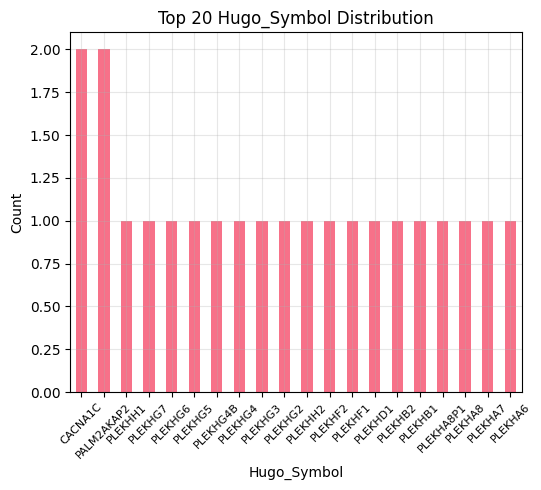


Visualizing distribution of CNA values for a few sample columns...


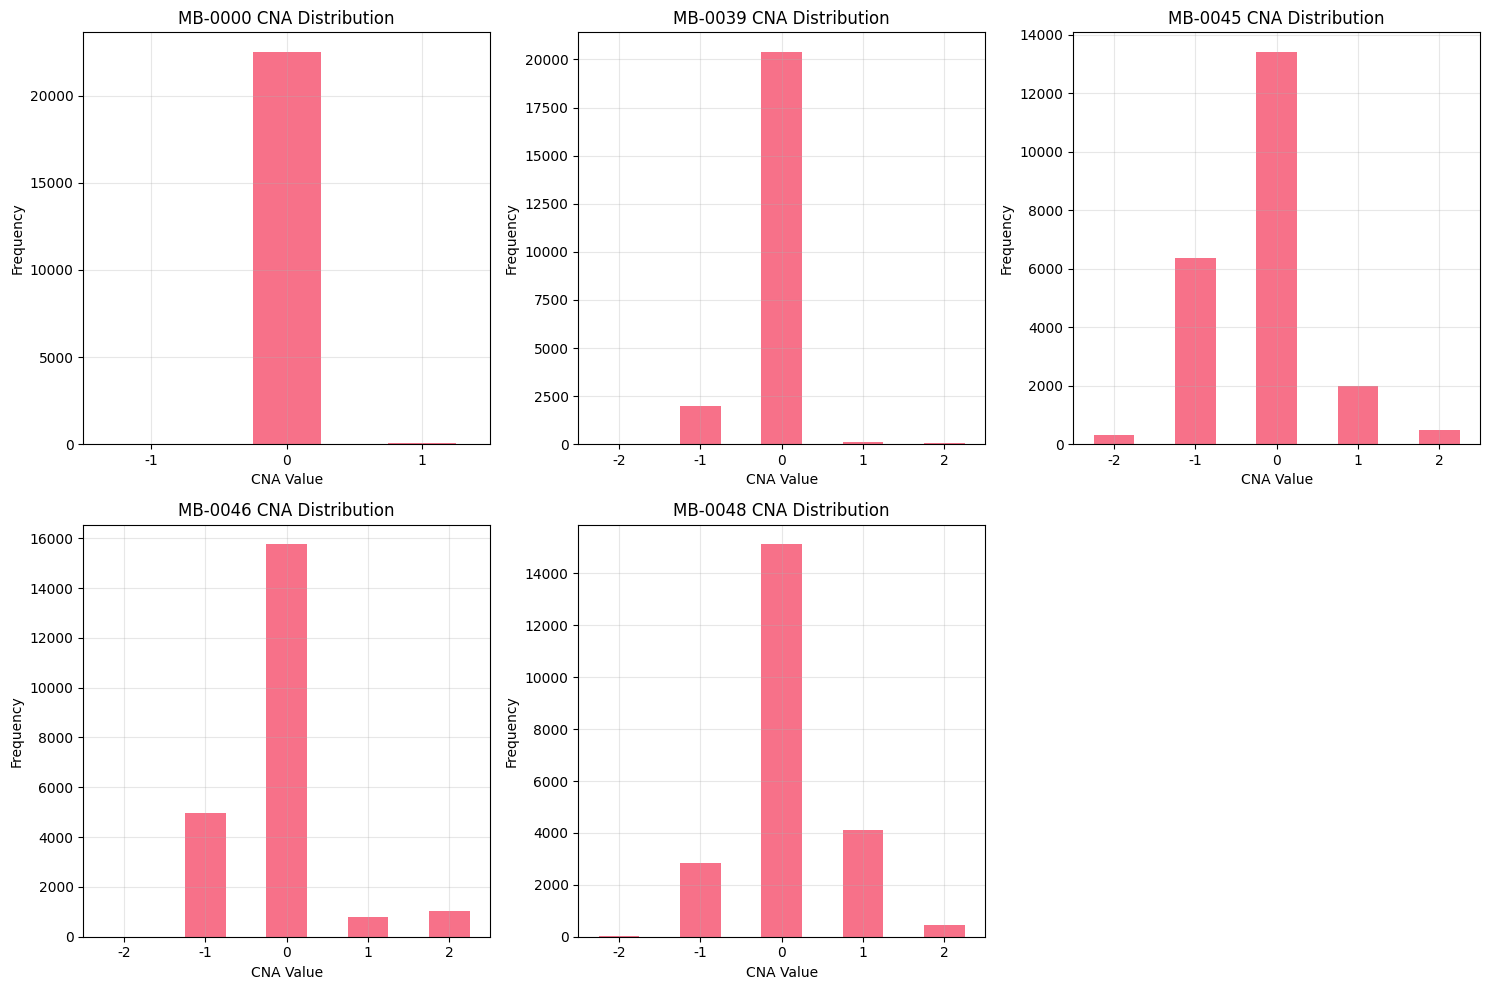

In [ ]:
# 1. Print the data types of each column
print('Data types of each column:')
print(df.dtypes)

# 2. Identify columns suitable for visualization
# Categorical columns: Object type, exclude columns with too many unique values or all NaNs
# Numerical columns: int or float type

categorical_cols = []
numerical_cols = []

# Check if the current file is the CNA data file
is_cna_file = 'data_cna.txt' in str(file_path)

for col in df.columns:
    if df[col].dtype == 'object':
        # For CNA data, Hugo_Symbol might be the only relevant object column for categorical plot
        if is_cna_file and col == 'Hugo_Symbol':
             categorical_cols.append(col)
        # For other files, consider object columns with a reasonable number of unique values
        elif not is_cna_file and df[col].nunique() < 50 and df[col].count() > 0: # Threshold for unique values can be adjusted
             categorical_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Check non-null count
        if df[col].count() > 0:
            numerical_cols.append(col)

print(f'\nIdentified categorical columns for visualization: {categorical_cols}')
print(f'Identified numerical columns for visualization: {numerical_cols}')


# 3. Visualize suitable categorical columns
if categorical_cols:
    n_cols = 3
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            try:
                value_counts = df[col].value_counts(dropna=False)
                # For columns with many unique values like Hugo_Symbol, plot top N
                if is_cna_file and col == 'Hugo_Symbol' and len(value_counts) > 20: # Plot top 20 for Hugo_Symbol
                     value_counts.head(20).plot(kind='bar', ax=axes[i])
                     axes[i].set_title(f'Top 20 {col} Distribution')
                else:
                    value_counts.plot(kind='bar', ax=axes[i])
                    axes[i].set_title(f'{col} Distribution')

                axes[i].set_ylabel('Count')
                axes[i].grid(True, alpha=0.3)
                # Rotate labels if needed
                if len(value_counts) > 5 or value_counts.index.astype(str).str.len().max() > 10:
                     axes[i].tick_params(axis='x', rotation=45, labelsize=8)
            except Exception as e:
                print(f"Could not plot categorical column {col}: {e}")


    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(results_dir / f'{Path(current_file).stem}_categorical_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable categorical columns found for visualization.")

# 4. Visualize suitable numerical columns
if numerical_cols:
    if is_cna_file:
        print("\nVisualizing distribution of CNA values for a few sample columns...")
        # Select a few sample columns for visualization (e.g., first 5 sample columns, excluding Entrez_Gene_Id)
        sample_cols = [col for col in numerical_cols if col != 'Entrez_Gene_Id']
        sample_cols_to_plot = sample_cols[:5] # Adjust number as needed

        if sample_cols_to_plot:
            n_cols = 3
            n_rows = (len(sample_cols_to_plot) + n_cols - 1) // n_cols

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
            if len(sample_cols_to_plot) == 1:
                axes = [axes]
            else:
                axes = axes.flatten()

            for i, col in enumerate(sample_cols_to_plot):
                if i < len(axes):
                    try:
                        # Count occurrences of CNA values (-2, -1, 0, 1, 2)
                        value_counts = df[col].value_counts(dropna=False).sort_index()
                        value_counts.plot(kind='bar', ax=axes[i])
                        axes[i].set_title(f'{col} CNA Distribution')
                        axes[i].set_xlabel('CNA Value')
                        axes[i].set_ylabel('Frequency')
                        axes[i].grid(True, alpha=0.3)
                        axes[i].tick_params(axis='x', rotation=0) # Keep CNA values horizontal
                    except Exception as e:
                        print(f"Could not plot numerical column {col}: {e}")

            # Hide empty subplots
            if len(sample_cols_to_plot) > 1:
                for j in range(i+1, len(axes)):
                    axes[j].set_visible(False)
            elif len(sample_cols_to_plot) == 0 and len(axes) > 0:
                 for j in range(len(axes)):
                    axes[j].set_visible(False)


            plt.tight_layout()
            plt.savefig(results_dir / f'{Path(current_file).stem}_sample_distribution.png', dpi=300, bbox_inches='tight')
            plt.show()
        else:
             print("No sample columns selected for visualization.")
    else:
        # Plot histograms for other numerical columns
        n_cols = 3
        n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        if len(numerical_cols) == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, col in enumerate(numerical_cols):
            if i < len(axes):
                try:
                    numeric_data = pd.to_numeric(df[col], errors='coerce')
                    axes[i].hist(numeric_data.dropna(), bins=50, alpha=0.7, edgecolor='black')
                    axes[i].set_title(f'{col} Distribution')
                    axes[i].set_xlabel(col)
                    axes[i].set_ylabel('Frequency')
                    if numeric_data.count() > 0: # Avoid plotting mean for empty data
                        axes[i].axvline(numeric_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {numeric_data.mean():.2f}')
                        axes[i].legend()
                    axes[i].grid(True, alpha=0.3)
                except Exception as e:
                    print(f"Could not plot numerical column {col}: {e}")

        # Hide empty subplots
        if len(numerical_cols) > 1:
            for j in range(i+1, len(axes)):
                axes[j].set_visible(False)
        elif len(numerical_cols) == 0 and len(axes) > 0:
             for j in range(len(axes)):
                axes[j].set_visible(False)


        plt.tight_layout()
        plt.savefig(results_dir / f'{Path(current_file).stem}_numeric_features_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("\nNo suitable numerical columns found for visualization.")

In [ ]:
# Store findings in a dictionary
file_insights = {}

file_name = current_file
file_insights[file_name] = {}

# File dimensions
file_insights[file_name]['shape'] = df.shape

# Missing values summary
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
missing_info = missing_percent[missing_percent > 0].to_dict()
file_insights[file_name]['missing_values'] = missing_info

# Data types
file_insights[file_name]['data_types'] = df.dtypes.astype(str).to_dict()

# Key feature distributions and observations
observations = []

# Check if the current file is the CNA data file
is_cna_file = 'data_cna.txt' in str(file_path)

if is_cna_file:
    observations.append("This file contains Copy Number Alteration (CNA) data.")
    observations.append(f"The data includes CNA values (-2, -1, 0, 1, 2) for {df.shape[1] - 2} samples across {df.shape[0]} genes.")
    # Observation about missing values in Entrez_Gene_Id
    if 'Entrez_Gene_Id' in missing_info:
        observations.append(f"The 'Entrez_Gene_Id' column has a notable percentage of missing values ({missing_info['Entrez_Gene_Id']:.2f}%) and may require handling.")
    # Observation about missing values in sample columns (if any)
    sample_missing_cols = {col: percent for col, percent in missing_info.items() if col.startswith('MB-') or col.startswith('MTS-')}
    if sample_missing_cols:
        observations.append(f"Several sample columns have small percentages of missing values (e.g., {list(sample_missing_cols.keys())[:5]}...).")

    # Observation about the nature of numerical data (CNA values)
    observations.append("The numerical columns represent discrete CNA values (-2, -1, 0, 1, or 2).")

else: # For other file types if needed in the future
    # Observations about missing values in non-CNA files
    if missing_info:
        observations.append(f"Columns with missing values: {', '.join(missing_info.keys())}.")
        # Identify columns with 100% missing values (assuming 'Unnamed' pattern)
        unnamed_missing_cols = [col for col, percent in missing_info.items() if 'Unnamed' in col and percent == 100.0]
        if unnamed_missing_cols:
             observations.append(f"Columns {', '.join(unnamed_missing_cols)} have 100% missing values and should likely be dropped.")
        # Identify columns with notable missing values (excluding 100% missing)
        notable_missing_cols = [col for col, percent in missing_info.items() if col not in unnamed_missing_cols]
        if notable_missing_cols:
            observations.append(f"Columns {', '.join(notable_missing_cols)} have notable percentages of missing values that may need imputation or handling.")

    # Observations about categorical features (from previous identification)
    if 'categorical_cols' in locals() and categorical_cols:
        single_value_cols = [col for col in categorical_cols if df[col].nunique(dropna=False) <= 2]
        if single_value_cols:
            observations.append(f"Several categorical columns ({', '.join(single_value_cols)}) appear to have only one or two unique values (including NaN), which might limit their predictive power.")

    # Observations about numerical features (from previous identification and describe)
    if 'numerical_cols' in locals() and numerical_cols:
        for col in numerical_cols:
            # Check for skewed distribution (simple check, could be improved)
            try:
                numeric_data = pd.to_numeric(df[col], errors='coerce').dropna()
                if not numeric_data.empty:
                    skewness = numeric_data.skew()
                    if abs(skewness) > 1: # Threshold for high skewness
                         observations.append(f"Numerical feature '{col}' appears to be highly skewed (skewness: {skewness:.2f}).")
                    else:
                         observations.append(f"Numerical feature '{col}' distribution appears relatively symmetric (skewness: {skewness:.2f}).")
            except Exception as e:
                print(f"Could not calculate skewness for column {col}: {e}")


file_insights[file_name]['observations'] = observations

# Print the summary
print(f"\n=== Summary for {file_name} ===")
print(f"Shape: {file_insights[file_name]['shape']}")
print("\nMissing Values (%):")
if file_insights[file_name]['missing_values']:
    for col, percent in file_insights[file_name]['missing_values'].items():
        print(f"- {col}: {percent:.2f}%")
else:
    print("No missing values found.")
print("\nData Types:")
for col, dtype in file_insights[file_name]['data_types'].items():
     print(f"- {col}: {dtype}")
print("\nObservations:")
if file_insights[file_name]['observations']:
    for obs in file_insights[file_name]['observations']:
        print(f"- {obs}")
else:
    print("No specific observations noted.")

# You would typically store this in a list of insights dictionaries if processing multiple files
# For this single file subtask, we just print and conceptualize storage.
# Example: all_files_insights.append(file_insights)


=== Summary for data_cna.txt ===
Shape: (22544, 2175)

Missing Values (%):
- Entrez_Gene_Id: 15.20%
- MB-0008: 0.26%
- MB-0127: 0.14%
- MB-3253: 0.04%
- MB-4602: 0.18%
- MB-5172: 0.10%
- MB-5332: 0.20%
- MB-5417: 0.12%
- MB-5614: 0.13%
- MB-6329: 0.12%
- MB-7249: 0.18%
- MB-0059: 0.01%
- MB-0071: 0.09%
- MB-0099: 0.15%
- MB-0153: 0.01%
- MB-0159: 0.03%
- MB-0160: 0.05%
- MB-0169: 0.02%
- MB-0185: 0.04%
- MB-0283: 0.08%
- MB-0299: 0.02%
- MB-0327: 0.18%
- MB-0333: 0.20%
- MB-0347: 0.02%
- MB-0351: 0.14%
- MB-0390: 0.18%
- MB-0403: 0.01%
- MB-0405: 0.10%
- MB-0423: 0.19%
- MB-0432: 0.08%
- MB-0435: 0.01%
- MB-0448: 0.13%
- MB-0499: 0.19%
- MB-0539: 0.25%
- MB-0543: 0.04%
- MB-0546: 0.29%
- MB-0549: 0.19%
- MB-0564: 0.03%
- MB-0592: 0.01%
- MB-0667: 0.04%
- MB-0907: 0.02%
- MB-3547: 0.14%
- MB-3823: 0.15%
- MB-4298: 0.31%
- MB-4823: 0.18%
- MB-5022: 0.23%
- MB-5076: 0.05%
- MB-5104: 0.33%
- MB-5106: 0.21%
- MB-5109: 0.08%
- MB-5131: 0.25%
- MB-5136: 0.13%
- MB-5137: 0.16%
- MB-5140: 0.16

In [ ]:
# Get the next remaining file name
current_file = remaining_files.pop(0)
print(f'Loading file: {current_file}')

# Construct the full path
file_path = data_dir / current_file

# Read the data file into a pandas DataFrame
# Assuming the separator is space(s) based on previous file analysis, and low_memory=False for large files
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Print shape, columns, and data types
print(f'\nShape: {df.shape}')
print('\nColumns:')
print(df.columns.tolist())
print('\nData types and info:')
df.info()

# Display the first few rows
print('\nFirst 5 rows:')
display(df.head())

Loading file: data_methylation_promoters_rrbs.txt

Shape: (13188, 1419)

Columns:
['Hugo_Symbol', 'MB-0006', 'MB-0028', 'MB-0035', 'MB-0046', 'MB-0050', 'MB-0053', 'MB-0054', 'MB-0062', 'MB-0064', 'MB-0068', 'MB-0112', 'MB-0113', 'MB-0114', 'MB-0119', 'MB-0120', 'MB-0121', 'MB-0123', 'MB-0124', 'MB-0125', 'MB-0126', 'MB-0127', 'MB-0128', 'MB-0129', 'MB-0130', 'MB-0131', 'MB-0133', 'MB-0134', 'MB-0135', 'MB-0136', 'MB-0138', 'MB-0140', 'MB-0142', 'MB-0143', 'MB-0144', 'MB-0145', 'MB-0146', 'MB-0147', 'MB-0148', 'MB-0149', 'MB-0150', 'MB-0151', 'MB-0152', 'MB-0154', 'MB-0155', 'MB-0157', 'MB-0162', 'MB-0163', 'MB-0164', 'MB-0165', 'MB-0166', 'MB-0167', 'MB-0168', 'MB-0169', 'MB-0170', 'MB-0171', 'MB-0172', 'MB-0173', 'MB-0174', 'MB-0175', 'MB-0176', 'MB-0177', 'MB-0178', 'MB-0179', 'MB-0180', 'MB-0181', 'MB-0184', 'MB-0188', 'MB-0189', 'MB-0191', 'MB-0192', 'MB-0193', 'MB-0194', 'MB-0195', 'MB-0197', 'MB-0198', 'MB-0199', 'MB-0201', 'MB-0202', 'MB-0203', 'MB-0204', 'MB-0205', 'MB-0206', 

,Hugo_Symbol,MB-0006,MB-0028,MB-0035,MB-0046,MB-0050,MB-0053,MB-0054,MB-0062,MB-0064,...,MB-7279,MB-7281,MB-7283,MB-7285,MB-7288,MB-7289,MB-7291,MB-7292,MB-7293,MB-7296
0,A2M,0.045031,0.066532,0.015487,0.102439,0.001905,0.039106,0.080311,0.007585,0.003140,...,0.0,0.108374,0.001916,0.004673,0.004049,0.000000,0.177112,0.015464,0.090909,0.1
1,A4GALT,0.017582,0.038095,0.033333,0.000000,0.009804,0.236311,0.023460,0.001227,0.004673,...,0.0,0.026393,0.202151,0.061224,0.000000,0.062745,0.039773,0.007752,0.011628,0.0
2,AAAS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003817,0.000000,...,0.0,0.000000,0.013043,0.000000,0.000000,0.011811,0.003401,0.000000,0.014151,0.0
3,AACS,0.000000,0.019802,0.000000,0.000000,0.000000,0.000000,0.032967,0.000000,0.012195,...,0.0,0.000000,0.026316,NaN,0.000000,0.000000,0.007194,0.000000,0.000000,0.0
4,AADACL2,0.870370,0.958763,0.987395,0.965517,0.969231,0.763359,0.979310,0.958904,0.845588,...,NaN,0.922414,0.962264,0.935484,0.812500,0.939163,0.921348,NaN,0.937500,1.0


In [ ]:
# Generate descriptive statistics for numerical columns
print('Descriptive statistics for numerical columns:')
display(df.describe())

# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df) * 100).round(2)

# Create a summary DataFrame for missing values
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

# Print the missing values summary (only columns with missing values)
print('\nMissing values summary:')
display(missing_summary[missing_summary['Missing Count'] > 0])

Descriptive statistics for numerical columns:


,MB-0006,MB-0028,MB-0035,MB-0046,MB-0050,MB-0053,MB-0054,MB-0062,MB-0064,MB-0068,...,MB-7279,MB-7281,MB-7283,MB-7285,MB-7288,MB-7289,MB-7291,MB-7292,MB-7293,MB-7296
count,12960.000000,13050.000000,12692.000000,12731.000000,12759.000000,12828.000000,13126.000000,13032.000000,12956.000000,13000.000000,...,12592.000000,12767.000000,12905.000000,11919.000000,12883.000000,13003.000000,12993.000000,12005.000000,12936.000000,11587.000000
mean,0.093633,0.113621,0.152208,0.100777,0.084532,0.116868,0.120608,0.090994,0.102650,0.103470,...,0.096341,0.099070,0.157936,0.108065,0.101134,0.090419,0.100491,0.120394,0.098838,0.129669
std,0.210547,0.237311,0.283713,0.227867,0.205552,0.235333,0.231056,0.218081,0.208574,0.226960,...,0.211196,0.214579,0.274570,0.212139,0.222536,0.212776,0.216512,0.225159,0.211131,0.256027
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.004082,0.000000,0.000000,0.000000,0.000000,0.005017,0.000000,0.005525,0.000000,...,0.000000,0.000000,0.004950,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001988,0.010417,0.002313,0.001083,0.001203,0.003049,0.012094,0.001606,0.013158,0.001267,...,0.001750,0.001984,0.016529,0.014706,0.001637,0.002613,0.003659,0.013761,0.002780,0.014286
75%,0.046316,0.054663,0.124012,0.040517,0.029851,0.093086,0.080434,0.024133,0.068729,0.058158,...,0.049867,0.062916,0.152245,0.075342,0.042032,0.036586,0.068182,0.104167,0.056808,0.070468
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Missing values summary:


,Missing Count,Missing Percent
MB-5205,4385,33.25
MB-0233,3502,26.55
MB-5259,3430,26.01
MB-3016,2929,22.21
MB-3252,2847,21.59
...,...,...
MB-5084,13,0.10
MB-4671,12,0.09
MB-4643,12,0.09
MB-4735,9,0.07


Data types of each column:
Hugo_Symbol     object
MB-0006        float64
MB-0028        float64
MB-0035        float64
MB-0046        float64
                ...   
MB-7289        float64
MB-7291        float64
MB-7292        float64
MB-7293        float64
MB-7296        float64
Length: 1419, dtype: object

Identified categorical columns for visualization: ['Hugo_Symbol']
Identified numerical columns for visualization: ['MB-0006', 'MB-0028', 'MB-0035', 'MB-0046', 'MB-0050', 'MB-0053', 'MB-0054', 'MB-0062', 'MB-0064', 'MB-0068', 'MB-0112', 'MB-0113', 'MB-0114', 'MB-0119', 'MB-0120', 'MB-0121', 'MB-0123', 'MB-0124', 'MB-0125', 'MB-0126', 'MB-0127', 'MB-0128', 'MB-0129', 'MB-0130', 'MB-0131', 'MB-0133', 'MB-0134', 'MB-0135', 'MB-0136', 'MB-0138', 'MB-0140', 'MB-0142', 'MB-0143', 'MB-0144', 'MB-0145', 'MB-0146', 'MB-0147', 'MB-0148', 'MB-0149', 'MB-0150', 'MB-0151', 'MB-0152', 'MB-0154', 'MB-0155', 'MB-0157', 'MB-0162', 'MB-0163', 'MB-0164', 'MB-0165', 'MB-0166', 'MB-0167', 'MB-0168', 'MB-

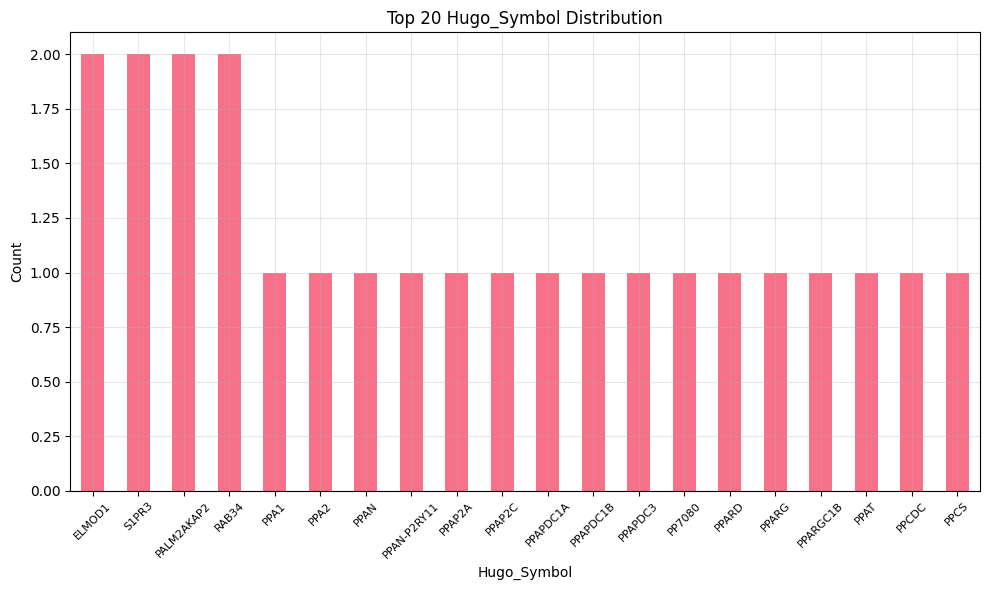


Visualizing distribution of methylation values for a few sample columns...


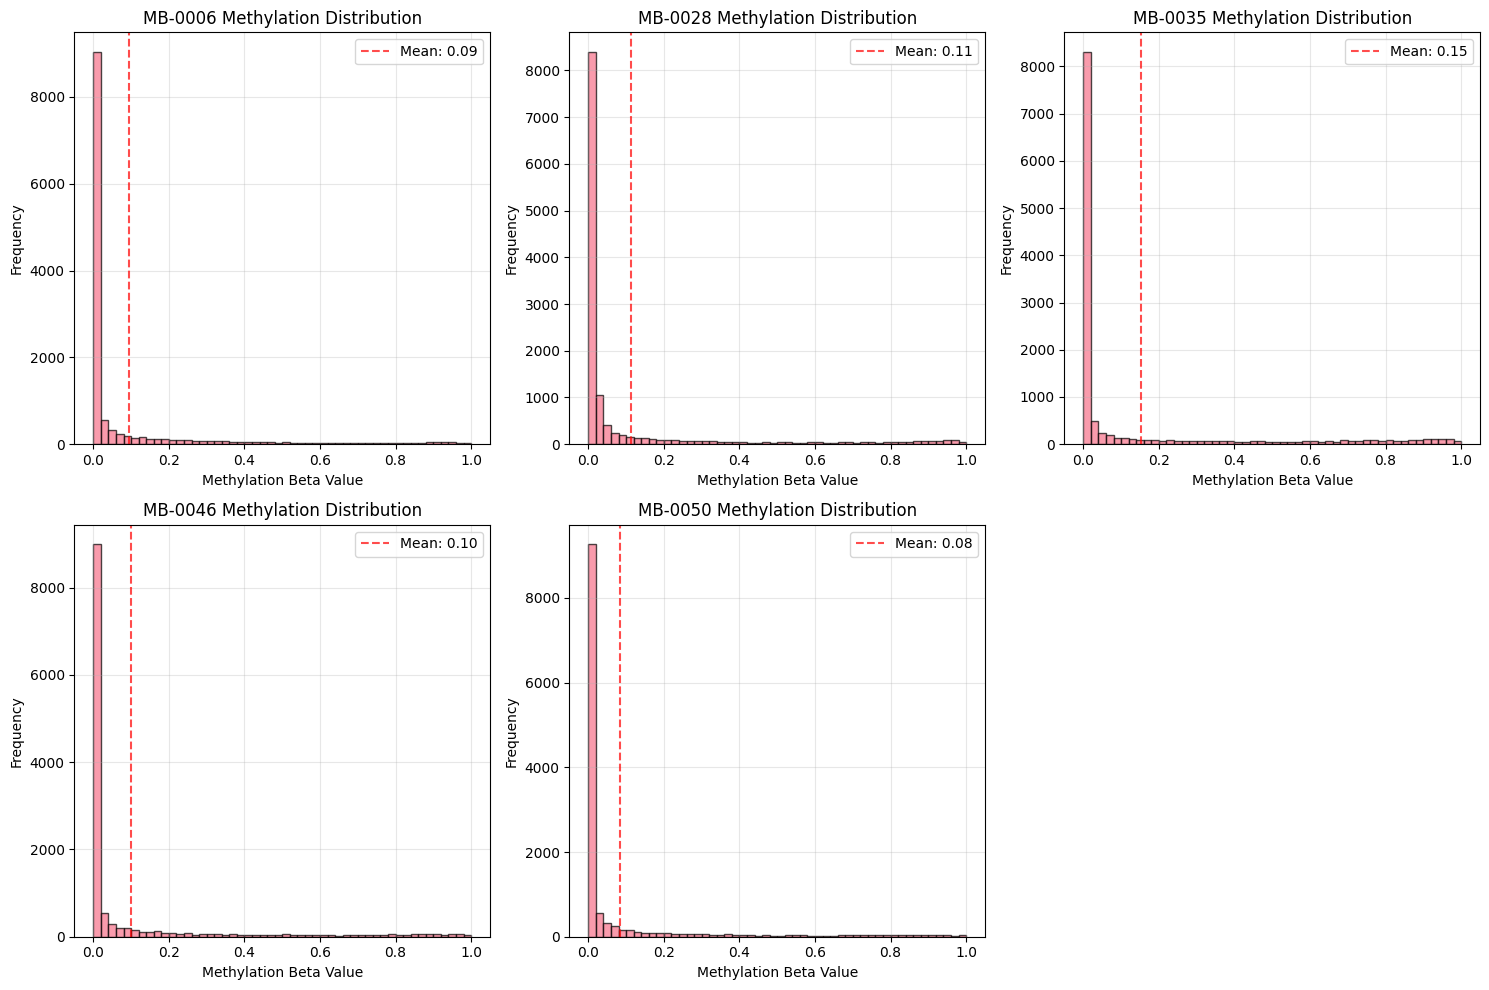

In [ ]:
# 1. Print the data types of each column
print('Data types of each column:')
print(df.dtypes)

# 2. Identify columns suitable for visualization
# Categorical columns: Object type, exclude columns with too many unique values or all NaNs
# Numerical columns: int or float type

categorical_cols = []
numerical_cols = []

# Check if the current file is the CNA data file
is_cna_file = 'data_cna.txt' in str(file_path)

for col in df.columns:
    if df[col].dtype == 'object':
        # For methylation data, Hugo_Symbol might be the only relevant object column
        if col == 'Hugo_Symbol':
             categorical_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Check non-null count
        if df[col].count() > 0:
            numerical_cols.append(col)

print(f'\nIdentified categorical columns for visualization: {categorical_cols}')
print(f'Identified numerical columns for visualization: {numerical_cols}')


# 3. Visualize suitable categorical columns
if categorical_cols:
    n_cols = 1 # Only Hugo_Symbol expected
    n_rows = len(categorical_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6 * n_rows))
    if n_rows == 1:
        axes = [axes] # Make it iterable even if only one plot


    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            try:
                value_counts = df[col].value_counts(dropna=False)
                # For columns with many unique values like Hugo_Symbol, plot top N
                if len(value_counts) > 20: # Plot top 20 for Hugo_Symbol
                     value_counts.head(20).plot(kind='bar', ax=axes[i])
                     axes[i].set_title(f'Top 20 {col} Distribution')
                else:
                    value_counts.plot(kind='bar', ax=axes[i])
                    axes[i].set_title(f'{col} Distribution')

                axes[i].set_ylabel('Count')
                axes[i].grid(True, alpha=0.3)
                # Rotate labels if needed
                if len(value_counts) > 5 or value_counts.index.astype(str).str.len().max() > 10:
                     axes[i].tick_params(axis='x', rotation=45, labelsize=8)
            except Exception as e:
                print(f"Could not plot categorical column {col}: {e}")


    plt.tight_layout()
    plt.savefig(results_dir / f'{Path(current_file).stem}_categorical_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable categorical columns found for visualization.")

# 4. Visualize distribution of methylation values for a few sample columns
# For methylation data, most columns are sample IDs with numerical methylation beta values (0 to 1).
# Visualizing all ~1400 sample columns is not practical.
# We can visualize the distribution of methylation values across a few sample columns as an example.
if numerical_cols:
    print("\nVisualizing distribution of methylation values for a few sample columns...")
    # Select a few sample columns for visualization (e.g., first 5 sample columns)
    sample_cols_to_plot = numerical_cols[:5] # Adjust number as needed

    if sample_cols_to_plot:
        n_cols = 3
        n_rows = (len(sample_cols_to_plot) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        if len(sample_cols_to_plot) == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, col in enumerate(sample_cols_to_plot):
            if i < len(axes):
                try:
                    # Plot histogram of methylation beta values (expected range 0 to 1)
                    numeric_data = pd.to_numeric(df[col], errors='coerce')
                    axes[i].hist(numeric_data.dropna(), bins=50, alpha=0.7, edgecolor='black', range=[0, 1])
                    axes[i].set_title(f'{col} Methylation Distribution')
                    axes[i].set_xlabel('Methylation Beta Value')
                    axes[i].set_ylabel('Frequency')
                    if numeric_data.count() > 0: # Avoid plotting mean for empty data
                         axes[i].axvline(numeric_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {numeric_data.mean():.2f}')
                         axes[i].legend()
                    axes[i].grid(True, alpha=0.3)
                    axes[i].tick_params(axis='x', rotation=0)
                except Exception as e:
                    print(f"Could not plot numerical column {col}: {e}")

        # Hide empty subplots
        if len(sample_cols_to_plot) > 1:
            for j in range(i+1, len(axes)):
                axes[j].set_visible(False)
        elif len(sample_cols_to_plot) == 0 and len(axes) > 0:
             for j in range(len(axes)):
                axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig(results_dir / f'{Path(current_file).stem}_sample_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
         print("No sample columns selected for visualization.")
else:
    print("\nNo suitable numerical columns found for visualization.")

In [ ]:
# Store findings in a dictionary
file_insights = {}

file_name = current_file
file_insights[file_name] = {}

# File dimensions
file_insights[file_name]['shape'] = df.shape

# Missing values summary
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
missing_info = missing_percent[missing_percent > 0].to_dict()
file_insights[file_name]['missing_values'] = missing_info

# Data types
file_insights[file_name]['data_types'] = df.dtypes.astype(str).to_dict()

# Key feature distributions and observations
observations = []

observations.append("This file contains methylation beta values for gene promoters.")
observations.append(f"The data includes methylation values for {df.shape[1] - 1} samples across {df.shape[0]} genes.")

# Observation about missing values in sample columns
if missing_info:
    sample_missing_cols = {col: percent for col, percent in missing_info.items() if col.startswith('MB-') or col.startswith('MTS-')}
    if sample_missing_cols:
        observations.append(f"Several sample columns have varying percentages of missing values (e.g., {list(sample_missing_cols.keys())[:5]}... with up to {max(sample_missing_cols.values()):.2f}% missing).")
    else:
         observations.append("No missing values found in sample columns.")

# Observation about the nature of numerical data (methylation beta values)
observations.append("The numerical columns represent methylation beta values, expected to be continuous values between 0 and 1.")

# Observation about the categorical feature (Hugo_Symbol)
if 'Hugo_Symbol' in df.columns:
     observations.append(f"The 'Hugo_Symbol' column identifies the genes, with {df['Hugo_Symbol'].nunique()} unique gene symbols.")

file_insights[file_name]['observations'] = observations

# Print the summary
print(f"\n=== Summary for {file_name} ===")
print(f"Shape: {file_insights[file_name]['shape']}")
print("\nMissing Values (%):")
if file_insights[file_name]['missing_values']:
    for col, percent in file_insights[file_name]['missing_values'].items():
        print(f"- {col}: {percent:.2f}%")
else:
    print("No missing values found.")
print("\nData Types:")
for col, dtype in file_insights[file_name]['data_types'].items():
     print(f"- {col}: {dtype}")
print("\nObservations:")
if file_insights[file_name]['observations']:
    for obs in file_insights[file_name]['observations']:
        print(f"- {obs}")
else:
    print("No specific observations noted.")

# You would typically store this in a list of insights dictionaries if processing multiple files
# For this single file subtask, we just print and conceptualize storage.
# Example: all_files_insights.append(file_insights)


=== Summary for data_methylation_promoters_rrbs.txt ===
Shape: (13188, 1419)

Missing Values (%):
- MB-0006: 1.73%
- MB-0028: 1.05%
- MB-0035: 3.76%
- MB-0046: 3.47%
- MB-0050: 3.25%
- MB-0053: 2.73%
- MB-0054: 0.47%
- MB-0062: 1.18%
- MB-0064: 1.76%
- MB-0068: 1.43%
- MB-0112: 5.37%
- MB-0113: 5.94%
- MB-0114: 17.11%
- MB-0119: 5.66%
- MB-0120: 8.42%
- MB-0121: 9.39%
- MB-0123: 1.51%
- MB-0124: 0.49%
- MB-0125: 1.24%
- MB-0126: 2.49%
- MB-0127: 2.79%
- MB-0128: 0.99%
- MB-0129: 2.53%
- MB-0130: 3.09%
- MB-0131: 1.65%
- MB-0133: 6.97%
- MB-0134: 4.98%
- MB-0135: 3.18%
- MB-0136: 9.39%
- MB-0138: 1.13%
- MB-0140: 3.78%
- MB-0142: 2.85%
- MB-0143: 3.55%
- MB-0144: 3.50%
- MB-0145: 0.77%
- MB-0146: 5.20%
- MB-0147: 1.27%
- MB-0148: 0.89%
- MB-0149: 3.65%
- MB-0150: 0.89%
- MB-0151: 8.79%
- MB-0152: 2.27%
- MB-0154: 5.76%
- MB-0155: 0.80%
- MB-0157: 0.69%
- MB-0162: 2.52%
- MB-0163: 6.85%
- MB-0164: 2.43%
- MB-0165: 1.17%
- MB-0166: 3.50%
- MB-0167: 6.19%
- MB-0168: 0.33%
- MB-0169: 6.09%

In [ ]:
# Get the next remaining file name
current_file = remaining_files.pop(0)
print(f'Loading file: {current_file}')

# Construct the full path
file_path = data_dir / current_file

# Read the data file into a pandas DataFrame
# Assuming the separator is space(s) based on previous file analysis, and low_memory=False for large files
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Print shape, columns, and data types
print(f'\nShape: {df.shape}')
print('\nColumns:')
print(df.columns.tolist())
print('\nData types and info:')
df.info()

# Display the first few rows
print('\nFirst 5 rows:')
display(df.head())

Loading file: data_gene_panel_matrix.txt

Shape: (2433, 2)

Columns:
['SAMPLE_ID', 'mutations']

Data types and info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2433 entries, 0 to 2432
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SAMPLE_ID  2433 non-null   object
 1   mutations  2433 non-null   object
dtypes: object(2)
memory usage: 38.1+ KB

First 5 rows:


,SAMPLE_ID,mutations
0,MB-0000,METABRIC_173
1,MB-0002,METABRIC_173
2,MB-0005,METABRIC_173
3,MB-0006,METABRIC_173
4,MB-0008,METABRIC_173


In [ ]:
# Generate descriptive statistics for numerical columns (will show nothing as there are none)
print('Descriptive statistics for numerical columns:')
display(df.describe())

# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df) * 100).round(2)

# Create a summary DataFrame for missing values
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

# Print the missing values summary (only columns with missing values)
print('\nMissing values summary:')
display(missing_summary[missing_summary['Missing Count'] > 0])

Descriptive statistics for numerical columns:


,SAMPLE_ID,mutations
count,2433,2433
unique,2433,1
top,MTS-T2432,METABRIC_173
freq,1,2433



Missing values summary:


,Missing Count,Missing Percent


Data types of each column:
SAMPLE_ID    object
mutations    object
dtype: object

Identified categorical columns for visualization: ['mutations']
Identified numerical columns for visualization: []


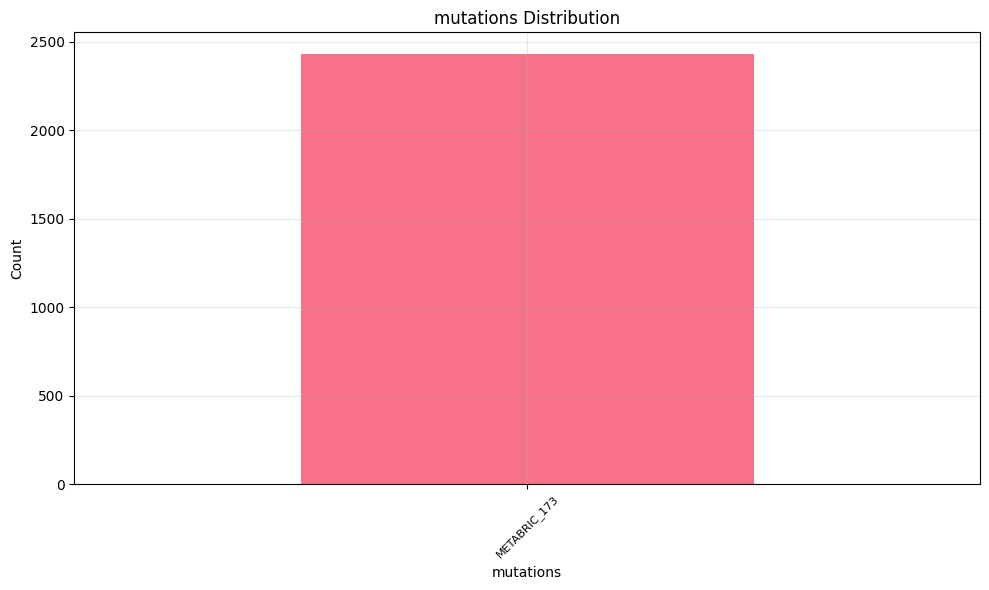


No numerical columns to visualize for this file.


In [ ]:
# 1. Print the data types of each column
print('Data types of each column:')
print(df.dtypes)

# 2. Identify columns suitable for visualization
# Categorical columns: Object type, exclude columns with too many unique values or all NaNs
# Numerical columns: int or float type

categorical_cols = []
numerical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        # Check number of unique values and non-null count
        # For gene panel matrix, both columns are object type, but 'mutations' has only 1 unique value
        if df[col].nunique() < 50 and df[col].count() > 0: # Threshold for unique values can be adjusted
             categorical_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Check non-null count
        if df[col].count() > 0:
            numerical_cols.append(col)

print(f'\nIdentified categorical columns for visualization: {categorical_cols}')
print(f'Identified numerical columns for visualization: {numerical_cols}')


# 3. Visualize suitable categorical columns
if categorical_cols:
    n_cols = 1 # Only 'mutations' expected for plotting
    n_rows = len(categorical_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6 * n_rows))
    if n_rows == 1:
        axes = [axes] # Make it iterable even if only one plot


    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            try:
                value_counts = df[col].value_counts(dropna=False)
                value_counts.plot(kind='bar', ax=axes[i])
                axes[i].set_title(f'{col} Distribution')
                axes[i].set_ylabel('Count')
                axes[i].grid(True, alpha=0.3)
                # Rotate labels if needed
                if len(value_counts) > 5 or value_counts.index.astype(str).str.len().max() > 10:
                     axes[i].tick_params(axis='x', rotation=45, labelsize=8)
            except Exception as e:
                print(f"Could not plot categorical column {col}: {e}")


    plt.tight_layout()
    plt.savefig(results_dir / f'{Path(current_file).stem}_categorical_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable categorical columns found for visualization.")

# 4. No numerical columns to visualize for this file
if not numerical_cols:
    print("\nNo numerical columns to visualize for this file.")

In [ ]:
# Store findings in a dictionary
file_insights = {}

file_name = current_file
file_insights[file_name] = {}

# File dimensions
file_insights[file_name]['shape'] = df.shape

# Missing values summary
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
missing_info = missing_percent[missing_percent > 0].to_dict()
file_insights[file_name]['missing_values'] = missing_info

# Data types
file_insights[file_name]['data_types'] = df.dtypes.astype(str).to_dict()

# Key feature distributions and observations
observations = []

observations.append("This file appears to be a gene panel matrix.")
observations.append(f"The data includes information for {df.shape[0]} entries and {df.shape[1]} columns.")

# Observation about missing values
if missing_info:
    observations.append(f"Columns with missing values: {', '.join(missing_info.keys())}.")
else:
     observations.append("No missing values found.")

# Observation about data types
observations.append("All columns are of object type, indicating potential categorical or identifier data.")

# Observation about the 'mutations' column (from previous analysis)
if 'mutations' in df.columns and df['mutations'].nunique(dropna=False) == 1:
     observations.append("The 'mutations' column has only one unique value, suggesting it might not be informative for differentiation.")

# Observation about the 'SAMPLE_ID' column (from previous analysis)
if 'SAMPLE_ID' in df.columns:
     observations.append("The 'SAMPLE_ID' column likely serves as an identifier.")


file_insights[file_name]['observations'] = observations

# Print the summary
print(f"\n=== Summary for {file_name} ===")
print(f"Shape: {file_insights[file_name]['shape']}")
print("\nMissing Values (%):")
if file_insights[file_name]['missing_values']:
    for col, percent in file_insights[file_name]['missing_values'].items():
        print(f"- {col}: {percent:.2f}%")
else:
    print("No missing values found.")
print("\nData Types:")
for col, dtype in file_insights[file_name]['data_types'].items():
     print(f"- {col}: {dtype}")
print("\nObservations:")
if file_insights[file_name]['observations']:
    for obs in file_insights[file_name]['observations']:
        print(f"- {obs}")
else:
    print("No specific observations noted.")

# You would typically store this in a list of insights dictionaries if processing multiple files
# For this single file subtask, we just print and conceptualize storage.
# Example: all_files_insights.append(file_insights)


=== Summary for data_gene_panel_matrix.txt ===
Shape: (2433, 2)

Missing Values (%):
No missing values found.

Data Types:
- SAMPLE_ID: object
- mutations: object

Observations:
- This file appears to be a gene panel matrix.
- The data includes information for 2433 entries and 2 columns.
- No missing values found.
- All columns are of object type, indicating potential categorical or identifier data.
- The 'mutations' column has only one unique value, suggesting it might not be informative for differentiation.
- The 'SAMPLE_ID' column likely serves as an identifier.


In [ ]:
# Get the next remaining file name
current_file = remaining_files.pop(0)
print(f'Loading file: {current_file}')

# Construct the full path
file_path = data_dir / current_file

# Read the data file into a pandas DataFrame
# Assuming the separator is space(s) based on previous file analysis, and low_memory=False for large files
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Print shape, columns, and data types
print(f'\nShape: {df.shape}')
print('\nColumns:')
print(df.columns.tolist())
print('\nData types and info:')
df.info()

# Display the first few rows
print('\nFirst 5 rows:')
display(df.head())

Loading file: data_clinical_patient.txt

Shape: (2513, 24)

Columns:
['#Patient Identifier', 'Lymph nodes examined positive', 'Nottingham prognostic index', 'Cellularity', 'Chemotherapy', 'Cohort', 'ER status measured by IHC', 'HER2 status measured by SNP6', 'Hormone Therapy', 'Inferred Menopausal State', 'Sex', 'Integrative Cluster', 'Age at Diagnosis', 'Overall Survival (Months)', 'Overall Survival Status', 'Pam50 + Claudin-low subtype', '3-Gene classifier subtype', "Patient's Vital Status", 'Primary Tumor Laterality', 'Radio Therapy', 'Tumor Other Histologic Subtype', 'Type of Breast Surgery', 'Relapse Free Status (Months)', 'Relapse Free Status']

Data types and info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   #Patient Identifier             2513 non-null   object
 1   Lymph nodes examined positi

,#Patient Identifier,Lymph nodes examined positive,Nottingham prognostic index,Cellularity,Chemotherapy,Cohort,ER status measured by IHC,HER2 status measured by SNP6,Hormone Therapy,Inferred Menopausal State,...,Overall Survival Status,Pam50 + Claudin-low subtype,3-Gene classifier subtype,Patient's Vital Status,Primary Tumor Laterality,Radio Therapy,Tumor Other Histologic Subtype,Type of Breast Surgery,Relapse Free Status (Months),Relapse Free Status
0,#Identifier to uniquely specify a patient.,Number of lymphnodes positive,Nottingham prognostic index,Tumor Content,Chemotherapy.,Cohort.,ER status measured by IHC,HER2 status measured by SNP6,Hormone Therapy,Inferred Menopausal State,...,Overall patient survival status.,Pam50 + Claudin-low subtype,3-Gene classifier subtype,The survival state of the person.,"For tumors in paired organs, designates the si...",Radio Therapy,Text to describe a tumor's histologic subtype ...,Type of Breast Surgery,Time until last follow-up or relapse (in months),Relapse Free Status (Recurred = cases where th...
1,#STRING,STRING,NUMBER,STRING,STRING,STRING,STRING,STRING,STRING,STRING,...,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,NUMBER,STRING
2,#1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,...,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS
4,MB-0000,10,6.044,NaN,NO,1,Positve,NEUTRAL,YES,Post,...,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.5,0:Not Recurred


In [ ]:
# Reload the data skipping the initial metadata rows and specifying the correct header
file_path = data_dir / current_file
df = pd.read_csv(file_path, sep='\t', skiprows=3, low_memory=False)

# Print shape, columns, and data types of the reloaded DataFrame
print(f'\nShape after skipping header rows: {df.shape}')
print('\nColumns after skipping header rows:')
print(df.columns.tolist())
print('\nData types and info after skipping header rows:')
df.info()

# Display the first few rows of the reloaded DataFrame
print('\nFirst 5 rows after skipping header rows:')
display(df.head())


Shape after skipping header rows: (2510, 24)

Columns after skipping header rows:
['#1', '1', '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '1.10', '1.11', '1.12', '1.13', '1.14', '1.15', '1.16', '1.17', '1.18', '1.19', '1.20', '1.21', '1.22']

Data types and info after skipping header rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   #1      2510 non-null   object
 1   1       2244 non-null   object
 2   1.1     2288 non-null   object
 3   1.2     1918 non-null   object
 4   1.3     1981 non-null   object
 5   1.4     2499 non-null   object
 6   1.5     2427 non-null   object
 7   1.6     1981 non-null   object
 8   1.7     1981 non-null   object
 9   1.8     1981 non-null   object
 10  1.9     2510 non-null   object
 11  1.10    1981 non-null   object
 12  1.11    2499 non-null   object
 13  1.12    1982 non-null   object
 14  1

,#1,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,...,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.20,1.21,1.22
0,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,...,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS
1,MB-0000,10,6.044,NaN,NO,1,Positve,NEUTRAL,YES,Post,...,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.5,0:Not Recurred
2,MB-0002,0,4.02,High,NO,1,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.6333333333333,0:Not Recurred
3,MB-0005,1,4.03,High,YES,1,Positve,NEUTRAL,YES,Pre,...,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.3,1:Recurred
4,MB-0006,3,4.05,Moderate,YES,1,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333333333,0:Not Recurred


In [ ]:
# Reload the data skipping the initial metadata rows and setting the header to the first meaningful row
file_path = data_dir / current_file
df = pd.read_csv(file_path, sep='\t', skiprows=3, header=0, low_memory=False)

# Print shape, columns, and data types of the reloaded DataFrame
print(f'\nShape after setting header: {df.shape}')
print('\nColumns after setting header:')
print(df.columns.tolist())
print('\nData types and info after setting header:')
df.info()

# Display the first few rows of the reloaded DataFrame
print('\nFirst 5 rows after setting header:')
display(df.head())


Shape after setting header: (2510, 24)

Columns after setting header:
['#1', '1', '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '1.10', '1.11', '1.12', '1.13', '1.14', '1.15', '1.16', '1.17', '1.18', '1.19', '1.20', '1.21', '1.22']

Data types and info after setting header:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   #1      2510 non-null   object
 1   1       2244 non-null   object
 2   1.1     2288 non-null   object
 3   1.2     1918 non-null   object
 4   1.3     1981 non-null   object
 5   1.4     2499 non-null   object
 6   1.5     2427 non-null   object
 7   1.6     1981 non-null   object
 8   1.7     1981 non-null   object
 9   1.8     1981 non-null   object
 10  1.9     2510 non-null   object
 11  1.10    1981 non-null   object
 12  1.11    2499 non-null   object
 13  1.12    1982 non-null   object
 14  1.13    1982 non-nu

,#1,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,...,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.20,1.21,1.22
0,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,...,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS
1,MB-0000,10,6.044,NaN,NO,1,Positve,NEUTRAL,YES,Post,...,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.5,0:Not Recurred
2,MB-0002,0,4.02,High,NO,1,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.6333333333333,0:Not Recurred
3,MB-0005,1,4.03,High,YES,1,Positve,NEUTRAL,YES,Pre,...,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.3,1:Recurred
4,MB-0006,3,4.05,Moderate,YES,1,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333333333,0:Not Recurred


In [ ]:
# Reload the data skipping the initial metadata rows and the row with generic headers
file_path = data_dir / current_file
df = pd.read_csv(file_path, sep='\t', skiprows=4, low_memory=False)

# Print shape, columns, and data types of the reloaded DataFrame
print(f'\nShape after skipping header row and metadata: {df.shape}')
print('\nColumns after skipping header row and metadata:')
print(df.columns.tolist())
print('\nData types and info after skipping header row and metadata:')
df.info()

# Display the first few rows of the reloaded DataFrame
print('\nFirst 5 rows after skipping header row and metadata:')
display(df.head())


Shape after skipping header row and metadata: (2509, 24)

Columns after skipping header row and metadata:
['PATIENT_ID', 'LYMPH_NODES_EXAMINED_POSITIVE', 'NPI', 'CELLULARITY', 'CHEMOTHERAPY', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HORMONE_THERAPY', 'INFERRED_MENOPAUSAL_STATE', 'SEX', 'INTCLUST', 'AGE_AT_DIAGNOSIS', 'OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE', 'THREEGENE', 'VITAL_STATUS', 'LATERALITY', 'RADIO_THERAPY', 'HISTOLOGICAL_SUBTYPE', 'BREAST_SURGERY', 'RFS_MONTHS', 'RFS_STATUS']

Data types and info after skipping header row and metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PATIENT_ID                     2509 non-null   object 
 1   LYMPH_NODES_EXAMINED_POSITIVE  2243 non-null   float64
 2   NPI                            2287 non-null   float64
 3   CELLULARITY                    1917 non

,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,...,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS
0,MB-0000,10.0,6.044,NaN,NO,1.0,Positve,NEUTRAL,YES,Post,...,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.500000,0:Not Recurred
1,MB-0002,0.0,4.020,High,NO,1.0,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.633333,0:Not Recurred
2,MB-0005,1.0,4.030,High,YES,1.0,Positve,NEUTRAL,YES,Pre,...,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.300000,1:Recurred
3,MB-0006,3.0,4.050,Moderate,YES,1.0,Positve,NEUTRAL,YES,Pre,...,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333,0:Not Recurred
4,MB-0008,8.0,6.080,High,YES,1.0,Positve,NEUTRAL,YES,Post,...,1:DECEASED,LumB,ER+/HER2- High Prolif,Died of Disease,Right,YES,Mixed,MASTECTOMY,18.800000,1:Recurred


In [ ]:
# Generate descriptive statistics for numerical columns
print('Descriptive statistics for numerical columns:')
display(df.describe())

# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df) * 100).round(2)

# Create a summary DataFrame for missing values
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

# Print the missing values summary (only columns with missing values)
print('\nMissing values summary:')
display(missing_summary[missing_summary['Missing Count'] > 0])

Descriptive statistics for numerical columns:


,LYMPH_NODES_EXAMINED_POSITIVE,NPI,COHORT,AGE_AT_DIAGNOSIS,OS_MONTHS,RFS_MONTHS
count,2243.000000,2287.000000,2498.000000,2498.000000,1981.000000,2388.000000
mean,1.950513,4.028787,2.900320,60.420300,125.244271,110.293649
std,4.017774,1.189092,1.962216,13.032997,76.111772,77.539698
min,0.000000,1.000000,1.000000,21.930000,0.000000,0.000000
25%,0.000000,3.048000,1.000000,50.920000,60.866667,41.100000
50%,0.000000,4.044000,3.000000,61.110000,116.466667,100.416667
75%,2.000000,5.040000,4.000000,70.000000,185.133333,169.875000
max,45.000000,7.200000,9.000000,96.290000,355.200000,389.333333



Missing values summary:


,Missing Count,Missing Percent
THREEGENE,745,29.69
LATERALITY,639,25.47
CELLULARITY,592,23.60
BREAST_SURGERY,554,22.08
HORMONE_THERAPY,529,21.08
CHEMOTHERAPY,529,21.08
HER2_SNP6,529,21.08
VITAL_STATUS,529,21.08
RADIO_THERAPY,529,21.08
INFERRED_MENOPAUSAL_STATE,529,21.08


Data types of each column:
PATIENT_ID                        object
LYMPH_NODES_EXAMINED_POSITIVE    float64
NPI                              float64
CELLULARITY                       object
CHEMOTHERAPY                      object
COHORT                           float64
ER_IHC                            object
HER2_SNP6                         object
HORMONE_THERAPY                   object
INFERRED_MENOPAUSAL_STATE         object
SEX                               object
INTCLUST                          object
AGE_AT_DIAGNOSIS                 float64
OS_MONTHS                        float64
OS_STATUS                         object
CLAUDIN_SUBTYPE                   object
THREEGENE                         object
VITAL_STATUS                      object
LATERALITY                        object
RADIO_THERAPY                     object
HISTOLOGICAL_SUBTYPE              object
BREAST_SURGERY                    object
RFS_MONTHS                       float64
RFS_STATUS                    

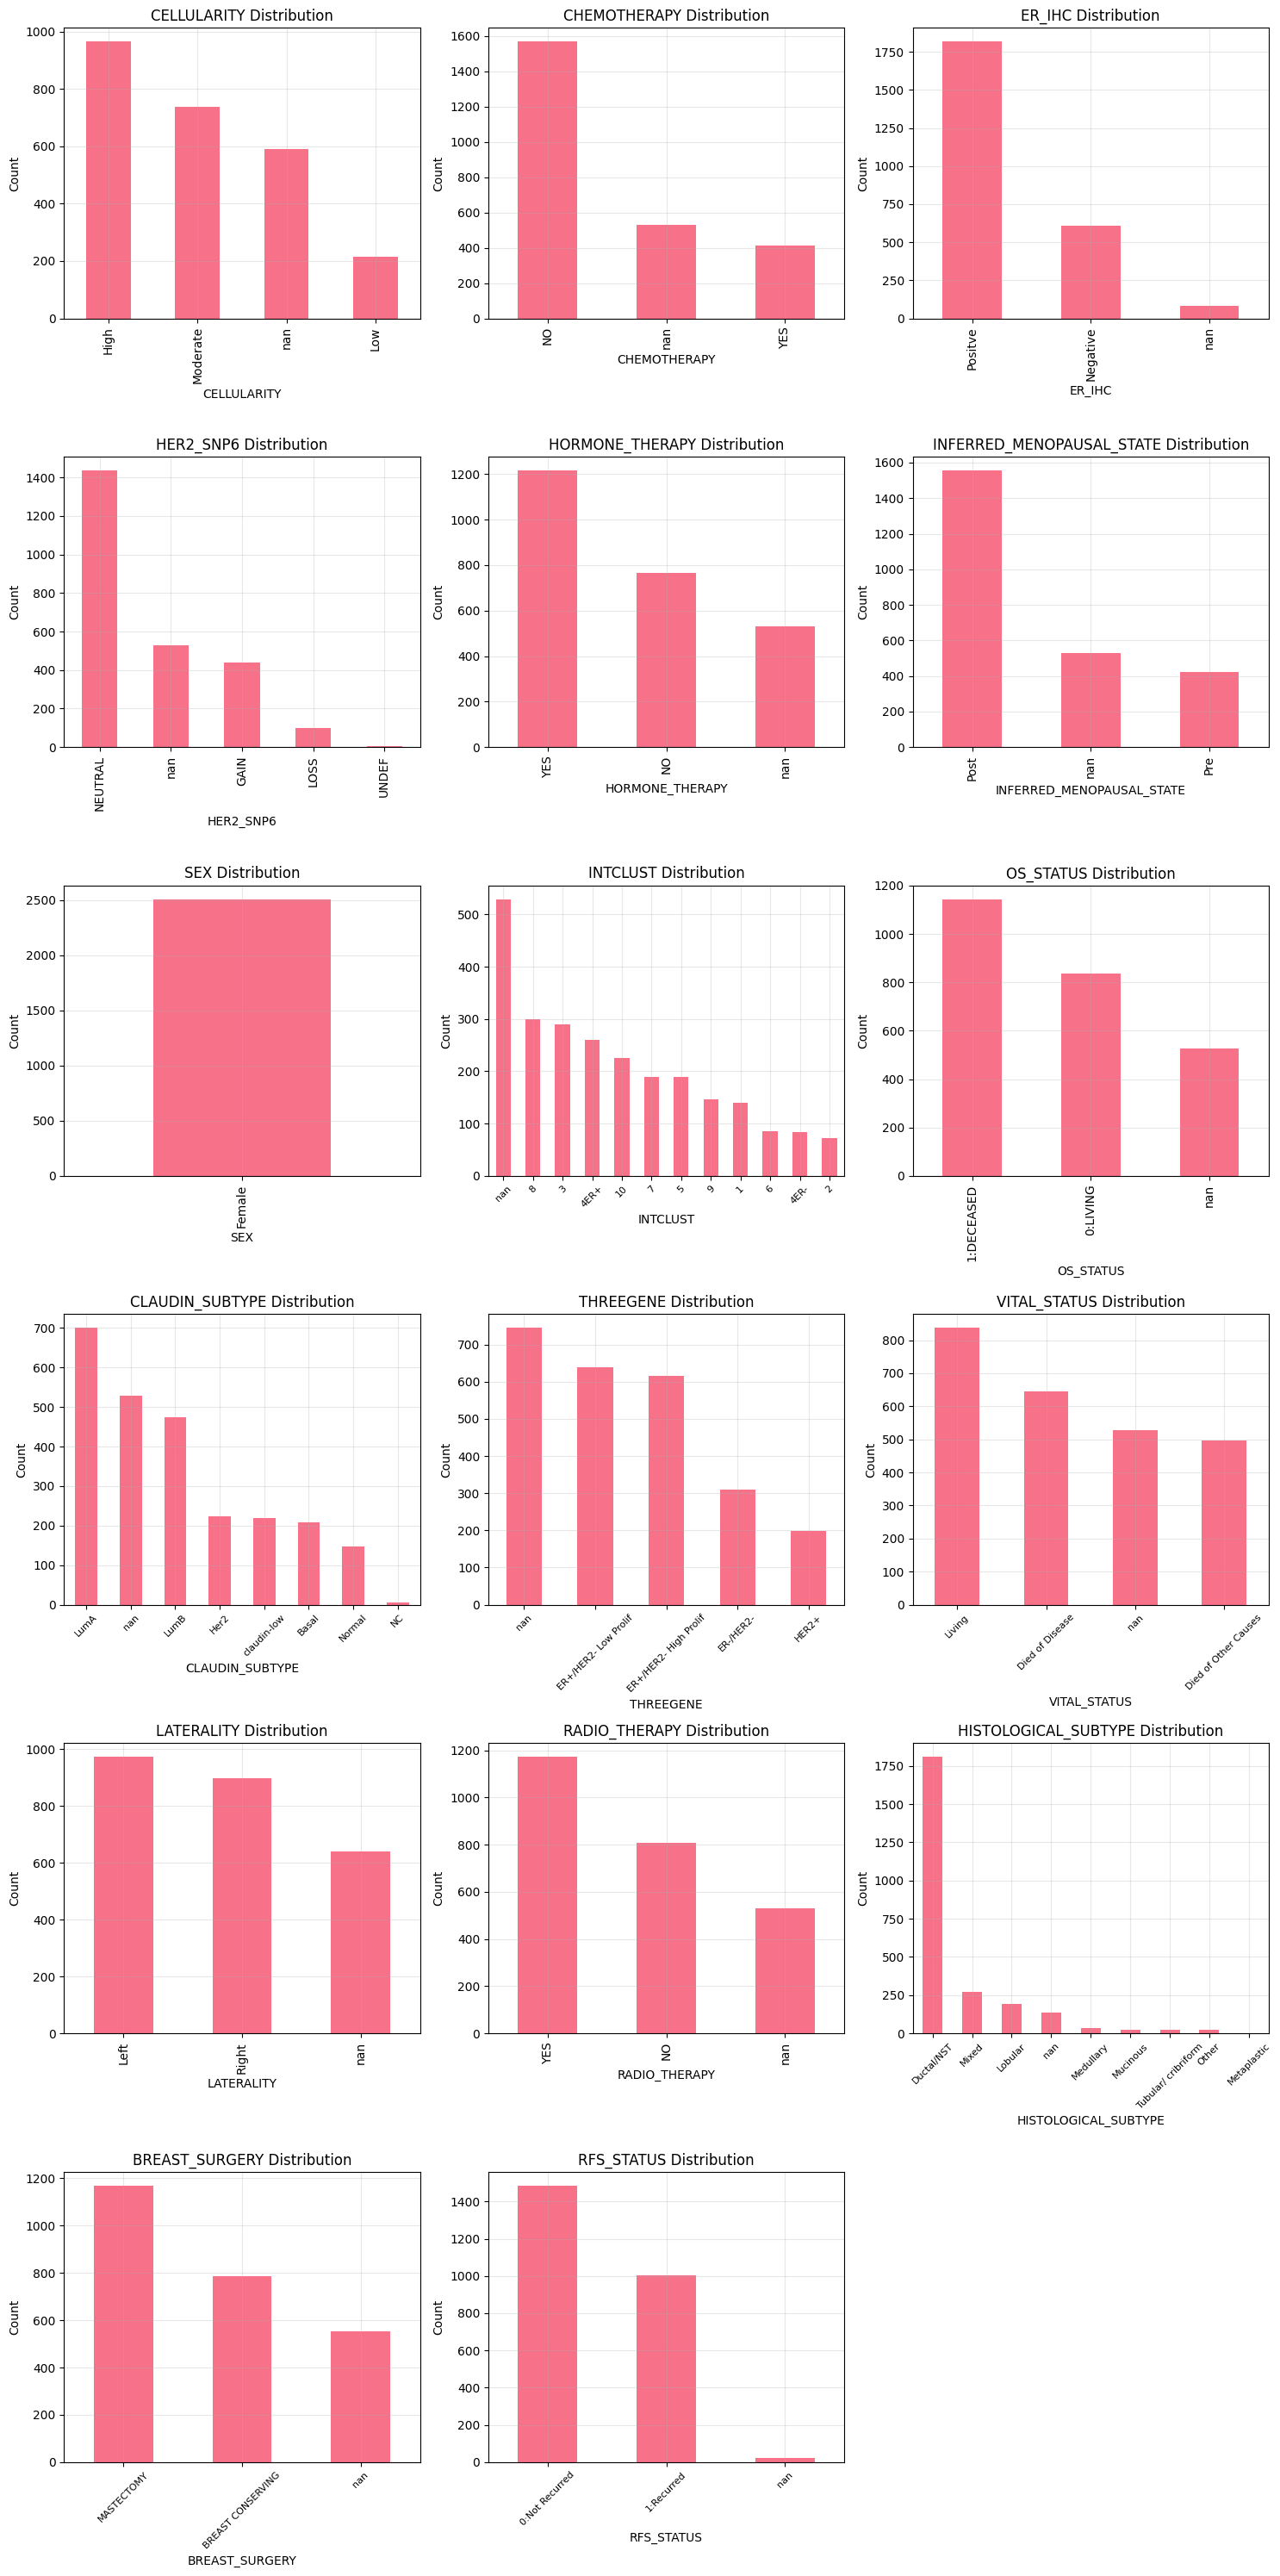

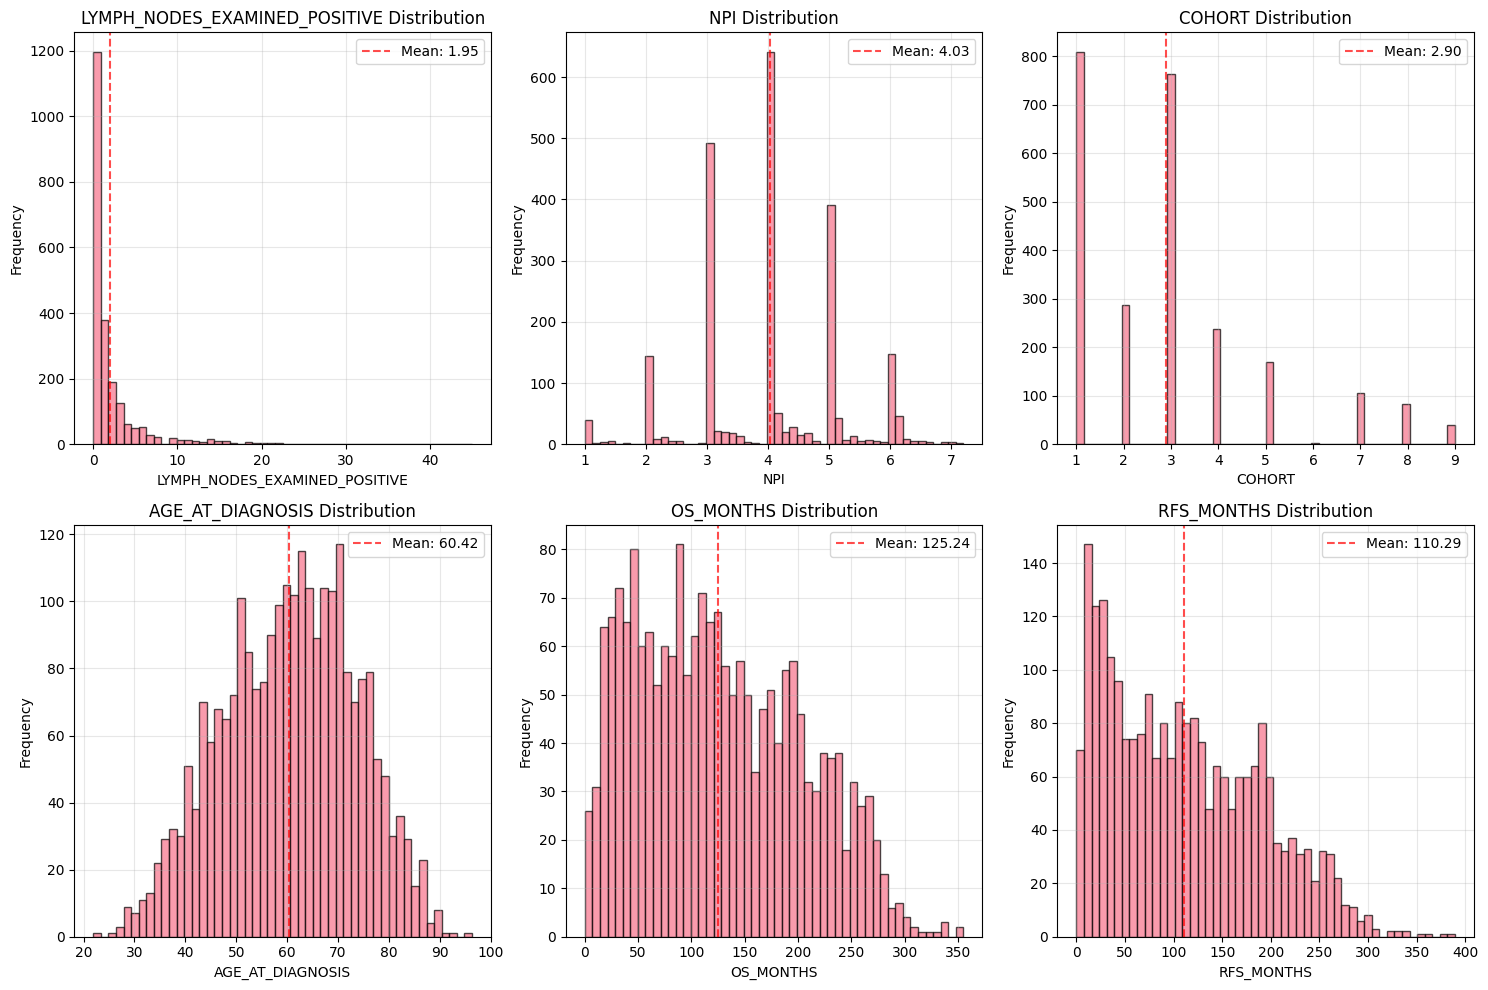

In [ ]:
# 1. Print the data types of each column
print('Data types of each column:')
print(df.dtypes)

# 2. Identify columns suitable for visualization
# Categorical columns: Object type, exclude columns with too many unique values or all NaNs
# Numerical columns: int or float type

categorical_cols = []
numerical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        # Check number of unique values and non-null count
        # Exclude Patient ID as it's an identifier
        if col != 'PATIENT_ID' and df[col].nunique() < 50 and df[col].count() > 0: # Threshold for unique values can be adjusted
             categorical_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Check non-null count and if it's not a patient ID (already excluded objects, but good to be sure)
        if df[col].count() > 0:
            numerical_cols.append(col)


print(f'\nIdentified categorical columns for visualization: {categorical_cols}')
print(f'Identified numerical columns for visualization: {numerical_cols}')


# 3. Visualize suitable categorical columns
if categorical_cols:
    n_cols = 3
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            try:
                value_counts = df[col].value_counts(dropna=False)
                value_counts.plot(kind='bar', ax=axes[i])
                axes[i].set_title(f'{col} Distribution')
                axes[i].set_ylabel('Count')
                axes[i].grid(True, alpha=0.3)
                # Rotate labels if needed
                if len(value_counts) > 5 or value_counts.index.astype(str).str.len().max() > 10:
                     axes[i].tick_params(axis='x', rotation=45, labelsize=8)
            except Exception as e:
                print(f"Could not plot categorical column {col}: {e}")


    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(results_dir / f'{Path(current_file).stem}_categorical_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable categorical columns found for visualization.")

# 4. Visualize suitable numerical columns
if numerical_cols:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if len(numerical_cols) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        if i < len(axes):
            try:
                numeric_data = pd.to_numeric(df[col], errors='coerce')
                axes[i].hist(numeric_data.dropna(), bins=50, alpha=0.7, edgecolor='black')
                axes[i].set_title(f'{col} Distribution')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Frequency')
                if numeric_data.count() > 0: # Avoid plotting mean for empty data
                    axes[i].axvline(numeric_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {numeric_data.mean():.2f}')
                    axes[i].legend()
                axes[i].grid(True, alpha=0.3)
            except Exception as e:
                print(f"Could not plot numerical column {col}: {e}")

    # Hide empty subplots
    if len(numerical_cols) > 1:
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
    elif len(numerical_cols) == 0 and len(axes) > 0:
         for j in range(len(axes)):
            axes[j].set_visible(False)


    plt.tight_layout()
    plt.savefig(results_dir / f'{Path(current_file).stem}_numeric_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable numerical columns found for visualization.")

In [ ]:
# Get the next remaining file name
current_file = remaining_files.pop(0)
print(f'Loading file: {current_file}')

# Construct the full path
file_path = data_dir / current_file

# Read the data file into a pandas DataFrame
# Assuming the separator is space(s) based on previous file analysis, and low_memory=False for large files
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Print shape, columns, and data types
print(f'\nShape: {df.shape}')
print('\nColumns:')
print(df.columns.tolist())
print('\nData types and info:')
df.info()

# Display the first few rows
print('\nFirst 5 rows:')
display(df.head())

Loading file: data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt

Shape: (20603, 1982)

Columns:
['Hugo_Symbol', 'Entrez_Gene_Id', 'MB-0362', 'MB-0346', 'MB-0386', 'MB-0574', 'MB-0185', 'MB-0503', 'MB-0641', 'MB-0201', 'MB-0218', 'MB-0316', 'MB-0189', 'MB-0891', 'MB-0658', 'MB-0899', 'MB-0605', 'MB-0258', 'MB-0506', 'MB-0420', 'MB-0223', 'MB-0445', 'MB-0199', 'MB-0517', 'MB-0155', 'MB-0428', 'MB-0117', 'MB-0906', 'MB-0249', 'MB-0660', 'MB-0497', 'MB-0434', 'MB-0143', 'MB-0513', 'MB-0541', 'MB-0653', 'MB-0455', 'MB-0540', 'MB-0384', 'MB-0637', 'MB-0157', 'MB-0443', 'MB-0584', 'MB-0292', 'MB-0322', 'MB-0501', 'MB-0401', 'MB-0140', 'MB-0606', 'MB-0666', 'MB-0598', 'MB-0453', 'MB-0138', 'MB-0579', 'MB-0405', 'MB-0471', 'MB-0347', 'MB-0619', 'MB-0171', 'MB-0310', 'MB-0621', 'MB-0614', 'MB-0372', 'MB-0374', 'MB-0382', 'MB-0327', 'MB-0066', 'MB-0144', 'MB-0596', 'MB-0164', 'MB-0215', 'MB-0146', 'MB-0229', 'MB-0505', 'MB-0102', 'MB-0569', 'MB-0516', 'MB-0272', 'MB-0585', 'MB-0494', 

,Hugo_Symbol,Entrez_Gene_Id,MB-0362,MB-0346,MB-0386,MB-0574,MB-0185,MB-0503,MB-0641,MB-0201,...,MB-6192,MB-4820,MB-5527,MB-5167,MB-5465,MB-5453,MB-5471,MB-5127,MB-4313,MB-4823
0,RERE,473,-0.7139,1.2266,-0.0053,-0.4399,-0.5958,0.4729,0.4974,-1.1900,...,-0.4596,1.8975,1.1120,1.1942,-1.7974,1.1339,0.0259,-0.3529,-1.2327,1.7217
1,RNF165,494470,-0.4606,0.3564,-0.6800,-1.0563,-0.0377,-0.6829,-0.2854,-0.4336,...,-1.0927,0.9103,-0.0023,-0.2898,3.5763,1.3429,0.5726,0.1731,0.5482,1.2239
2,PHF7,51533,-0.3325,-1.0617,0.2587,-0.2982,-1.2422,0.0558,-0.5011,-0.6418,...,-0.0725,0.7219,0.1402,0.8718,-0.9275,-0.0587,0.5240,-0.0311,4.4925,-0.2173
3,CIDEA,1149,-0.0129,-1.0394,3.2991,-0.2632,-1.0949,1.2628,2.0796,-0.8310,...,0.0679,-0.7126,-0.1523,-0.7593,-0.7141,-0.4324,-0.0336,-0.4003,2.4698,-0.7268
4,TENT2,167153,-0.7853,0.0337,-0.6649,2.1640,-0.2031,1.0304,0.6046,-1.7557,...,0.6400,-0.1102,1.2719,0.8178,-1.0301,0.6082,0.5608,2.4222,-3.2853,0.4181


In [ ]:
# Generate descriptive statistics for numerical columns
print('Descriptive statistics for numerical columns:')
display(df.describe())

# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df) * 100).round(2)

# Create a summary DataFrame for missing values
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

# Print the missing values summary (only columns with missing values)
print('\nMissing values summary:')
display(missing_summary[missing_summary['Missing Count'] > 0])

Descriptive statistics for numerical columns:


,Entrez_Gene_Id,MB-0362,MB-0346,MB-0386,MB-0574,MB-0185,MB-0503,MB-0641,MB-0201,MB-0218,...,MB-6192,MB-4820,MB-5527,MB-5167,MB-5465,MB-5453,MB-5471,MB-5127,MB-4313,MB-4823
count,2.060300e+04,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,...,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000
mean,2.128432e+06,-0.076835,0.044602,-0.030864,-0.032388,-0.007935,-0.038997,-0.057541,-0.058057,-0.016650,...,0.017030,0.081491,0.080641,0.023954,0.032188,0.009820,-0.016065,0.014534,0.149058,0.046979
std,1.410679e+07,0.882147,1.175542,0.874832,0.982613,0.991036,0.919516,0.960626,0.963604,0.958056,...,1.016565,1.330308,1.153600,0.930797,1.005030,0.931487,0.824156,0.980385,2.116958,1.001889
min,1.000000e+00,-3.921800,-5.351800,-4.396700,-9.158500,-4.167600,-3.642000,-4.267600,-4.102200,-4.283600,...,-4.461800,-5.236600,-3.647000,-4.028300,-3.675200,-3.585700,-3.590900,-5.400900,-6.476800,-6.980000
25%,7.501000e+03,-0.650500,-0.771550,-0.605550,-0.704350,-0.676550,-0.651800,-0.692900,-0.700450,-0.667800,...,-0.628550,-0.771750,-0.670750,-0.598000,-0.626300,-0.612800,-0.549600,-0.623250,-1.163150,-0.624350
50%,5.458700e+04,-0.115700,-0.082800,-0.074300,-0.122400,-0.079600,-0.086900,-0.125600,-0.107900,-0.099000,...,-0.091400,-0.058800,-0.057600,-0.043800,-0.060700,-0.066700,-0.071900,-0.031200,-0.061600,-0.038100
75%,1.338100e+05,0.468600,0.742300,0.513650,0.572650,0.587450,0.534000,0.502700,0.545900,0.553400,...,0.564250,0.772150,0.680450,0.598050,0.624700,0.574250,0.469900,0.616800,1.309100,0.652750
max,1.070751e+08,15.126500,8.202900,6.925800,8.949400,22.430300,7.777500,13.406300,11.182500,12.666000,...,11.771000,16.123600,10.542500,6.430100,9.120100,10.719600,6.283400,6.464900,14.760800,10.873300



Missing values summary:


,Missing Count,Missing Percent
MB-6018,1,0.0
MB-0241,1,0.0
MB-7013,1,0.0
MB-0876,1,0.0
MB-4876,1,0.0
MB-5373,1,0.0
MB-7168,1,0.0
MB-4722,1,0.0
MB-4705,1,0.0
MB-4557,1,0.0


Data types of each column:
Hugo_Symbol        object
Entrez_Gene_Id      int64
MB-0362           float64
MB-0346           float64
MB-0386           float64
                   ...   
MB-5453           float64
MB-5471           float64
MB-5127           float64
MB-4313           float64
MB-4823           float64
Length: 1982, dtype: object

Identified categorical columns for visualization: ['Hugo_Symbol']
Identified numerical columns for visualization: ['Entrez_Gene_Id', 'MB-0362', 'MB-0346', 'MB-0386', 'MB-0574', 'MB-0185', 'MB-0503', 'MB-0641', 'MB-0201', 'MB-0218', 'MB-0316', 'MB-0189', 'MB-0891', 'MB-0658', 'MB-0899', 'MB-0605', 'MB-0258', 'MB-0506', 'MB-0420', 'MB-0223', 'MB-0445', 'MB-0199', 'MB-0517', 'MB-0155', 'MB-0428', 'MB-0117', 'MB-0906', 'MB-0249', 'MB-0660', 'MB-0497', 'MB-0434', 'MB-0143', 'MB-0513', 'MB-0541', 'MB-0653', 'MB-0455', 'MB-0540', 'MB-0384', 'MB-0637', 'MB-0157', 'MB-0443', 'MB-0584', 'MB-0292', 'MB-0322', 'MB-0501', 'MB-0401', 'MB-0140', 'MB-0606', 'MB-0666

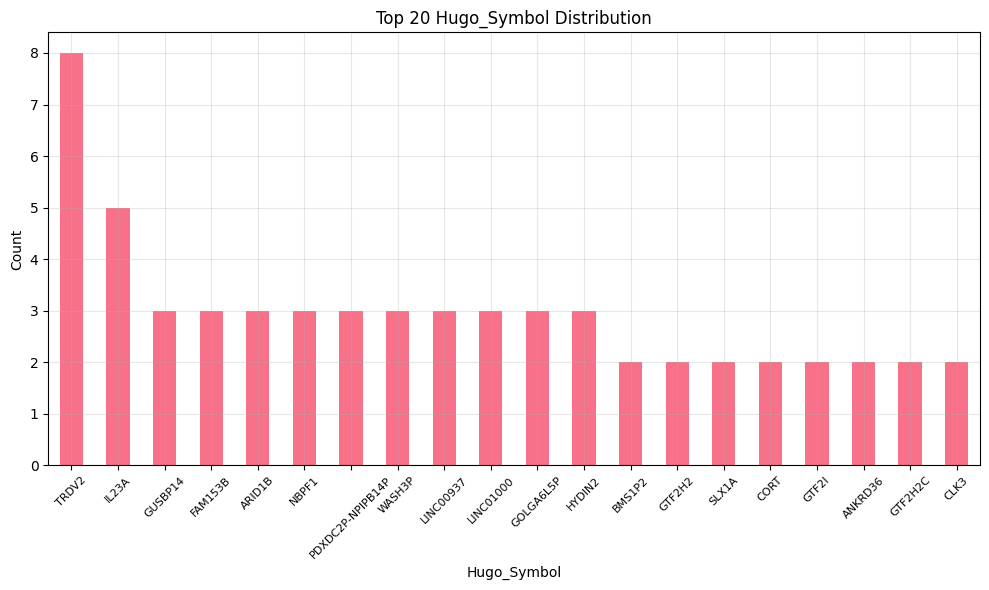


Visualizing distribution of numerical values for a few sample columns from data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt...


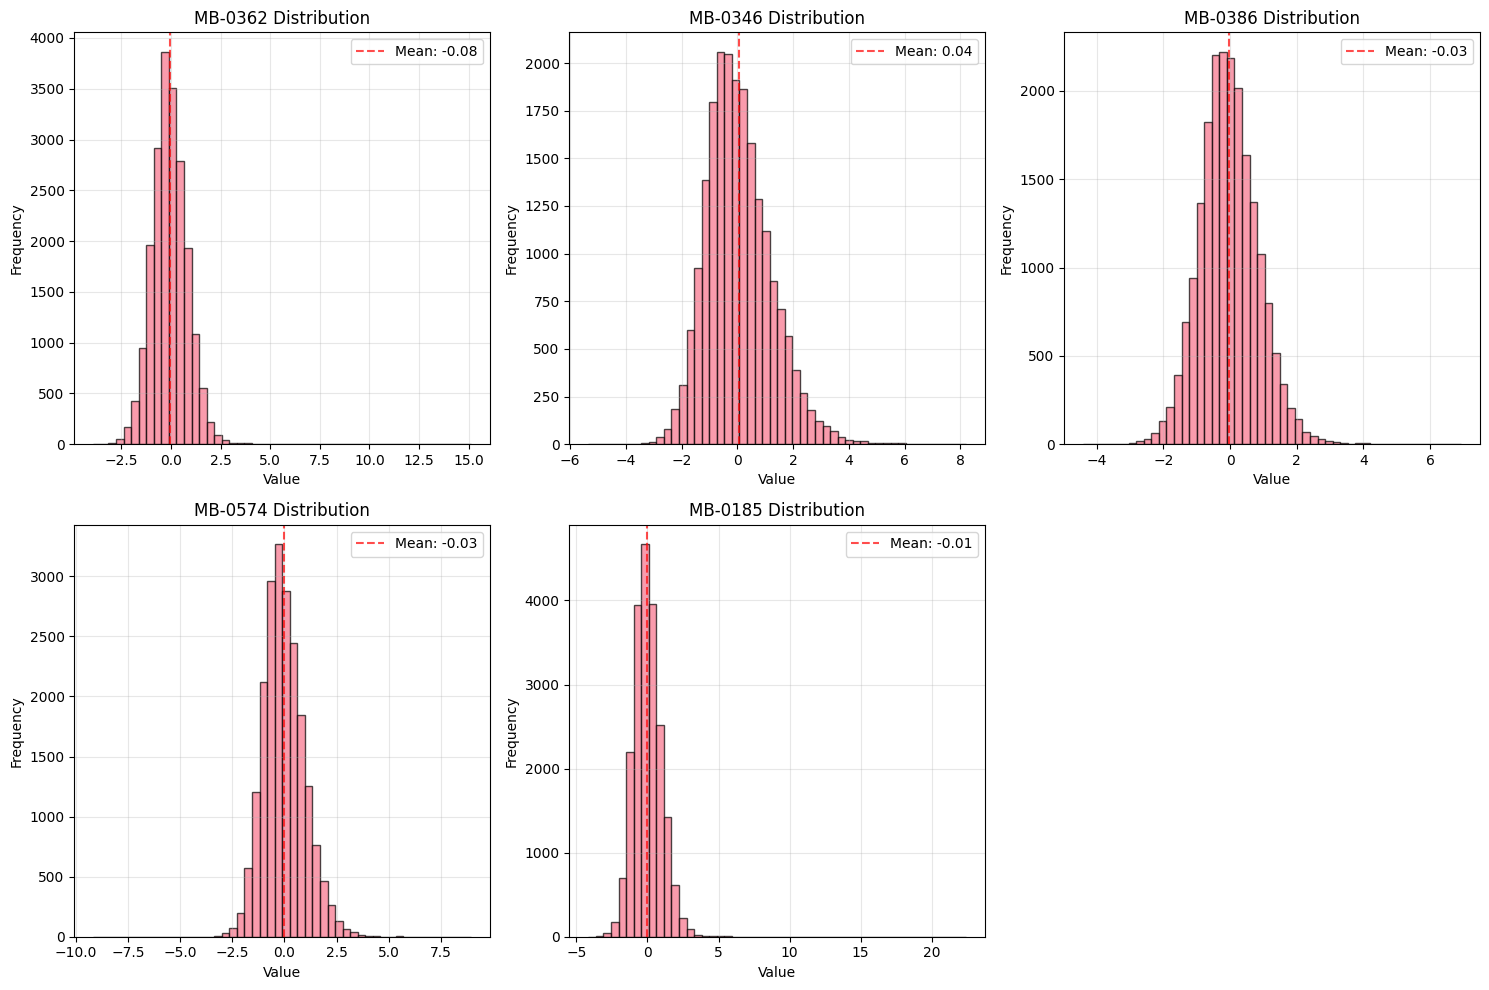

In [ ]:
# 1. Print the data types of each column
print('Data types of each column:')
print(df.dtypes)

# 2. Identify columns suitable for visualization
# Categorical columns: Object type, exclude columns with too many unique values or all NaNs
# Numerical columns: int or float type

categorical_cols = []
numerical_cols = []

# Check if the current file is the CNA data file
is_cna_file = 'data_cna.txt' in str(file_path)
is_methylation_file = 'data_methylation_promoters_rrbs.txt' in str(file_path)
is_mrna_zscores_file = 'data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt' in str(file_path)

for col in df.columns:
    if df[col].dtype == 'object':
        # For molecular data, Hugo_Symbol might be the only relevant object column
        if col == 'Hugo_Symbol':
             categorical_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Check non-null count
        if df[col].count() > 0:
            numerical_cols.append(col)

print(f'\nIdentified categorical columns for visualization: {categorical_cols}')
print(f'Identified numerical columns for visualization: {numerical_cols}')


# 3. Visualize suitable categorical columns
if categorical_cols:
    n_cols = 1 # Only Hugo_Symbol expected
    n_rows = len(categorical_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6 * n_rows))
    if n_rows == 1:
        axes = [axes] # Make it iterable even if only one plot


    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            try:
                value_counts = df[col].value_counts(dropna=False)
                # For columns with many unique values like Hugo_Symbol, plot top N
                if len(value_counts) > 20: # Plot top 20 for Hugo_Symbol
                     value_counts.head(20).plot(kind='bar', ax=axes[i])
                     axes[i].set_title(f'Top 20 {col} Distribution')
                else:
                    value_counts.plot(kind='bar', ax=axes[i])
                    axes[i].set_title(f'{col} Distribution')

                axes[i].set_ylabel('Count')
                axes[i].grid(True, alpha=0.3)
                # Rotate labels if needed
                if len(value_counts) > 5 or value_counts.index.astype(str).str.len().max() > 10:
                     axes[i].tick_params(axis='x', rotation=45, labelsize=8)
            except Exception as e:
                print(f"Could not plot categorical column {col}: {e}")


    plt.tight_layout()
    plt.savefig(results_dir / f'{Path(current_file).stem}_categorical_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable categorical columns found for visualization.")

# 4. Visualize distribution of numerical values for a few sample columns
# For molecular data (CNA, Methylation, mRNA), most columns are sample IDs with numerical values.
# Visualizing all sample columns is not practical.
# We can visualize the distribution of values across a few sample columns as an example.
if numerical_cols:
    print(f"\nVisualizing distribution of numerical values for a few sample columns from {Path(current_file).name}...")
    # Select a few sample columns for visualization (e.g., first 5 sample columns)
    sample_cols = [col for col in numerical_cols if col != 'Entrez_Gene_Id']
    sample_cols_to_plot = sample_cols[:5] # Adjust number as needed

    if sample_cols_to_plot:
        n_cols = 3
        n_rows = (len(sample_cols_to_plot) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        if len(sample_cols_to_plot) == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, col in enumerate(sample_cols_to_plot):
            if i < len(axes):
                try:
                    numeric_data = pd.to_numeric(df[col], errors='coerce')
                    # Plot histogram of numerical values
                    axes[i].hist(numeric_data.dropna(), bins=50, alpha=0.7, edgecolor='black')
                    axes[i].set_title(f'{col} Distribution')
                    axes[i].set_xlabel('Value')
                    axes[i].set_ylabel('Frequency')
                    if numeric_data.count() > 0: # Avoid plotting mean for empty data
                         axes[i].axvline(numeric_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {numeric_data.mean():.2f}')
                         axes[i].legend()
                    axes[i].grid(True, alpha=0.3)
                    axes[i].tick_params(axis='x', rotation=0)
                except Exception as e:
                    print(f"Could not plot numerical column {col}: {e}")

        # Hide empty subplots
        if len(sample_cols_to_plot) > 1:
            for j in range(i+1, len(axes)):
                axes[j].set_visible(False)
        elif len(sample_cols_to_plot) == 0 and len(axes) > 0:
             for j in range(len(axes)):
                axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig(results_dir / f'{Path(current_file).stem}_sample_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
         print("No sample columns selected for visualization.")
else:
    print("\nNo suitable numerical columns found for visualization.")

In [ ]:
# Store findings in a dictionary
file_insights = {}

file_name = current_file
file_insights[file_name] = {}

# File dimensions
file_insights[file_name]['shape'] = df.shape

# Missing values summary
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
missing_info = missing_percent[missing_percent > 0].to_dict()
file_insights[file_name]['missing_values'] = missing_info

# Data types
file_insights[file_name]['data_types'] = df.dtypes.astype(str).to_dict()

# Key feature distributions and observations
observations = []

observations.append("This file contains mRNA expression data (Z-scores).")
observations.append(f"The data includes expression values for {df.shape[1] - 2} samples across {df.shape[0]} genes.")

# Observation about missing values in sample columns
if missing_info:
    # Exclude Entrez_Gene_Id from sample missing columns
    sample_missing_cols = {col: percent for col, percent in missing_info.items() if col.startswith('MB-') or col.startswith('MTS-')}
    if sample_missing_cols:
        observations.append(f"Several sample columns have small percentages of missing values (e.g., {list(sample_missing_cols.keys())[:5]}... with up to {max(sample_missing_cols.values()):.2f}% missing).")
    else:
         observations.append("No missing values found in sample columns.")
elif 'Entrez_Gene_Id' in missing_info:
     observations.append(f"The 'Entrez_Gene_Id' column has a notable percentage of missing values ({missing_info['Entrez_Gene_Id']:.2f}%) and may require handling.")
else:
    observations.append("No missing values found.")


# Observation about the nature of numerical data (mRNA Z-scores)
observations.append("The numerical columns represent mRNA expression Z-scores, which are standardized values.")

# Observation about the categorical feature (Hugo_Symbol)
if 'Hugo_Symbol' in df.columns:
     observations.append(f"The 'Hugo_Symbol' column identifies the genes, with {df['Hugo_Symbol'].nunique()} unique gene symbols.")


file_insights[file_name]['observations'] = observations

# Print the summary
print(f"\n=== Summary for {file_name} ===")
print(f"Shape: {file_insights[file_name]['shape']}")
print("\nMissing Values (%):")
if file_insights[file_name]['missing_values']:
    for col, percent in file_insights[file_name]['missing_values'].items():
        print(f"- {col}: {percent:.2f}%")
else:
    print("No missing values found.")
print("\nData Types:")
for col, dtype in file_insights[file_name]['data_types'].items():
     print(f"- {col}: {dtype}")
print("\nObservations:")
if file_insights[file_name]['observations']:
    for obs in file_insights[file_name]['observations']:
        print(f"- {obs}")
else:
    print("No specific observations noted.")

# You would typically store this in a list of insights dictionaries if processing multiple files
# For this single file subtask, we just print and conceptualize storage.
# Example: all_files_insights.append(file_insights)


=== Summary for data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt ===
Shape: (20603, 1982)

Missing Values (%):
No missing values found.

Data Types:
- Hugo_Symbol: object
- Entrez_Gene_Id: int64
- MB-0362: float64
- MB-0346: float64
- MB-0386: float64
- MB-0574: float64
- MB-0185: float64
- MB-0503: float64
- MB-0641: float64
- MB-0201: float64
- MB-0218: float64
- MB-0316: float64
- MB-0189: float64
- MB-0891: float64
- MB-0658: float64
- MB-0899: float64
- MB-0605: float64
- MB-0258: float64
- MB-0506: float64
- MB-0420: float64
- MB-0223: float64
- MB-0445: float64
- MB-0199: float64
- MB-0517: float64
- MB-0155: float64
- MB-0428: float64
- MB-0117: float64
- MB-0906: float64
- MB-0249: float64
- MB-0660: float64
- MB-0497: float64
- MB-0434: float64
- MB-0143: float64
- MB-0513: float64
- MB-0541: float64
- MB-0653: float64
- MB-0455: float64
- MB-0540: float64
- MB-0384: float64
- MB-0637: float64
- MB-0157: float64
- MB-0443: float64
- MB-0584: float64
- MB-0292: f

In [ ]:
# Get the next remaining file name
current_file = remaining_files.pop(0)
print(f'Loading file: {current_file}')

# Construct the full path
file_path = data_dir / current_file

# Read the data file into a pandas DataFrame
# Assuming the separator is space(s) based on previous file analysis, and low_memory=False for large files
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Print shape, columns, and data types
print(f'\nShape: {df.shape}')
print('\nColumns:')
print(df.columns.tolist())
print('\nData types and info:')
df.info()

# Display the first few rows
print('\nFirst 5 rows:')
display(df.head())

Loading file: data_mrna_illumina_microarray.txt

Shape: (20603, 1982)

Columns:
['Hugo_Symbol', 'Entrez_Gene_Id', 'MB-0362', 'MB-0346', 'MB-0386', 'MB-0574', 'MB-0185', 'MB-0503', 'MB-0641', 'MB-0201', 'MB-0218', 'MB-0316', 'MB-0189', 'MB-0891', 'MB-0658', 'MB-0899', 'MB-0605', 'MB-0258', 'MB-0506', 'MB-0420', 'MB-0223', 'MB-0445', 'MB-0199', 'MB-0517', 'MB-0155', 'MB-0428', 'MB-0117', 'MB-0906', 'MB-0249', 'MB-0660', 'MB-0497', 'MB-0434', 'MB-0143', 'MB-0513', 'MB-0541', 'MB-0653', 'MB-0455', 'MB-0540', 'MB-0384', 'MB-0637', 'MB-0157', 'MB-0443', 'MB-0584', 'MB-0292', 'MB-0322', 'MB-0501', 'MB-0401', 'MB-0140', 'MB-0606', 'MB-0666', 'MB-0598', 'MB-0453', 'MB-0138', 'MB-0579', 'MB-0405', 'MB-0471', 'MB-0347', 'MB-0619', 'MB-0171', 'MB-0310', 'MB-0621', 'MB-0614', 'MB-0372', 'MB-0374', 'MB-0382', 'MB-0327', 'MB-0066', 'MB-0144', 'MB-0596', 'MB-0164', 'MB-0215', 'MB-0146', 'MB-0229', 'MB-0505', 'MB-0102', 'MB-0569', 'MB-0516', 'MB-0272', 'MB-0585', 'MB-0494', 'MB-0306', 'MB-0463', 'MB-01

,Hugo_Symbol,Entrez_Gene_Id,MB-0362,MB-0346,MB-0386,MB-0574,MB-0185,MB-0503,MB-0641,MB-0201,...,MB-6192,MB-4820,MB-5527,MB-5167,MB-5465,MB-5453,MB-5471,MB-5127,MB-4313,MB-4823
0,RERE,473,8.676978,9.653589,9.033589,8.814855,8.736406,9.274265,9.286585,8.437347,...,8.804947,9.991215,9.595923,9.637249,8.131637,9.606915,9.049296,8.858622,8.415867,9.902776
1,RNF165,494470,6.075331,6.687887,5.910885,5.628740,6.392422,5.908698,6.206729,6.095592,...,5.601472,7.103160,6.418987,6.203370,9.101942,7.427494,6.850000,6.550450,6.831722,7.338318
2,PHF7,51533,5.838270,5.600876,6.030718,5.849428,5.542133,5.964661,5.783374,5.737572,...,5.922894,6.181493,5.992153,6.230316,5.644587,5.927409,6.117095,5.936371,7.408960,5.875759
3,CIDEA,1149,6.397503,5.246319,10.111816,6.116868,5.184098,7.828171,8.744149,5.480091,...,6.488136,5.612846,6.241160,5.560488,5.611189,5.927031,6.374305,5.963092,9.181768,5.596873
4,TENT2,167153,7.906217,8.267256,7.959291,9.206376,8.162845,8.706646,8.518929,7.478413,...,8.534527,8.203819,8.813103,8.612911,7.798269,8.520545,8.499637,9.320207,6.804085,8.436732


In [ ]:
# Generate descriptive statistics for numerical columns
print('Descriptive statistics for numerical columns:')
display(df.describe())

# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df) * 100).round(2)

# Create a summary DataFrame for missing values
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percent
}).sort_values('Missing Count', ascending=False)

# Print the missing values summary (only columns with missing values)
print('\nMissing values summary:')
display(missing_summary[missing_summary['Missing Count'] > 0])

Descriptive statistics for numerical columns:


,Entrez_Gene_Id,MB-0362,MB-0346,MB-0386,MB-0574,MB-0185,MB-0503,MB-0641,MB-0201,MB-0218,...,MB-6192,MB-4820,MB-5527,MB-5167,MB-5465,MB-5453,MB-5471,MB-5127,MB-4313,MB-4823
count,2.060300e+04,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,...,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000
mean,2.128432e+06,6.690502,6.691272,6.700556,6.687998,6.703846,6.693769,6.694370,6.686680,6.703686,...,6.715400,6.707080,6.726353,6.703385,6.725051,6.732848,6.720591,6.703596,6.700417,6.727486
std,1.410679e+07,1.589279,1.606707,1.589527,1.595994,1.598439,1.591591,1.580722,1.587395,1.614311,...,1.609468,1.617596,1.626864,1.594981,1.621714,1.635385,1.615415,1.593411,1.655844,1.635746
min,1.000000e+00,4.719331,4.712744,4.713820,4.712950,4.697948,4.780887,4.756499,4.666984,4.724068,...,4.712942,4.714860,4.792811,4.712942,4.795059,4.712942,4.712942,4.712942,4.712942,4.724774
25%,7.501000e+03,5.470661,5.456328,5.477209,5.460084,5.473800,5.467824,5.473855,5.466941,5.456988,...,5.480688,5.478085,5.484310,5.477506,5.477190,5.480821,5.474965,5.475051,5.446425,5.477170
50%,5.458700e+04,6.026666,6.022480,6.056867,6.031509,6.038982,6.040759,6.041217,6.032249,6.042641,...,6.049678,6.010997,6.055947,6.042170,6.058256,6.068434,6.065052,6.049920,5.971177,6.058494
75%,1.338100e+05,7.579675,7.586581,7.587503,7.582243,7.602945,7.577778,7.583727,7.572498,7.598955,...,7.613770,7.588769,7.621432,7.592605,7.632426,7.633485,7.603878,7.605101,7.609041,7.631317
max,1.070751e+08,14.439220,14.521133,14.627355,14.436347,14.601087,14.466193,14.584569,14.284859,14.300028,...,14.425507,14.464282,14.464282,14.464282,14.453044,14.464282,14.449103,14.464282,14.464282,14.464282



Missing values summary:


,Missing Count,Missing Percent
MB-6018,1,0.0
MB-0241,1,0.0
MB-7013,1,0.0
MB-0876,1,0.0
MB-4876,1,0.0
MB-5373,1,0.0
MB-7168,1,0.0
MB-4722,1,0.0
MB-4705,1,0.0
MB-4557,1,0.0


Data types of each column:
Hugo_Symbol        object
Entrez_Gene_Id      int64
MB-0362           float64
MB-0346           float64
MB-0386           float64
                   ...   
MB-5453           float64
MB-5471           float64
MB-5127           float64
MB-4313           float64
MB-4823           float64
Length: 1982, dtype: object

Identified categorical columns for visualization: ['Hugo_Symbol']
Identified numerical columns for visualization: ['Entrez_Gene_Id', 'MB-0362', 'MB-0346', 'MB-0386', 'MB-0574', 'MB-0185', 'MB-0503', 'MB-0641', 'MB-0201', 'MB-0218', 'MB-0316', 'MB-0189', 'MB-0891', 'MB-0658', 'MB-0899', 'MB-0605', 'MB-0258', 'MB-0506', 'MB-0420', 'MB-0223', 'MB-0445', 'MB-0199', 'MB-0517', 'MB-0155', 'MB-0428', 'MB-0117', 'MB-0906', 'MB-0249', 'MB-0660', 'MB-0497', 'MB-0434', 'MB-0143', 'MB-0513', 'MB-0541', 'MB-0653', 'MB-0455', 'MB-0540', 'MB-0384', 'MB-0637', 'MB-0157', 'MB-0443', 'MB-0584', 'MB-0292', 'MB-0322', 'MB-0501', 'MB-0401', 'MB-0140', 'MB-0606', 'MB-0666

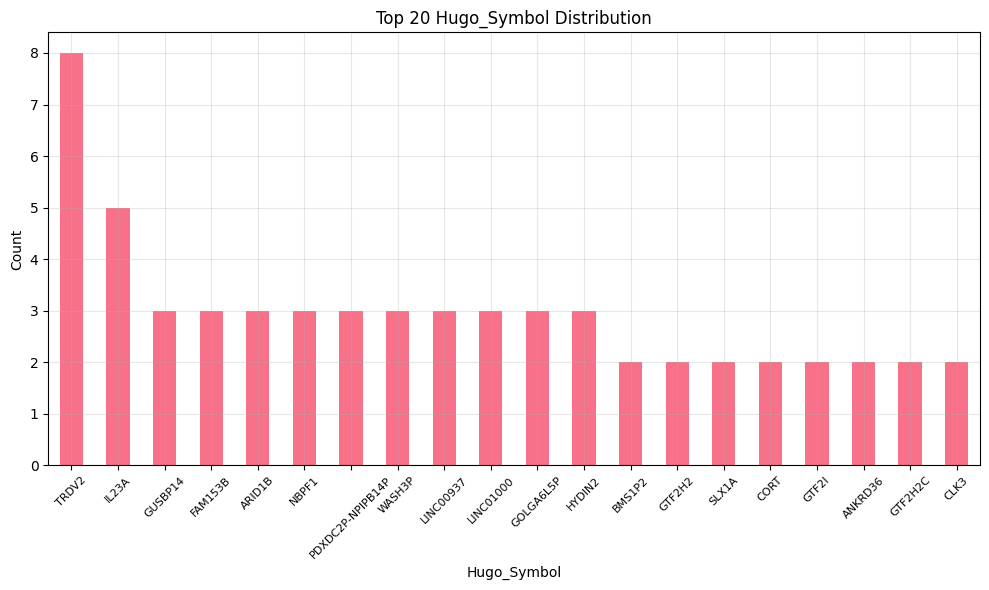


Visualizing distribution of numerical values for a few sample columns from data_mrna_illumina_microarray.txt...


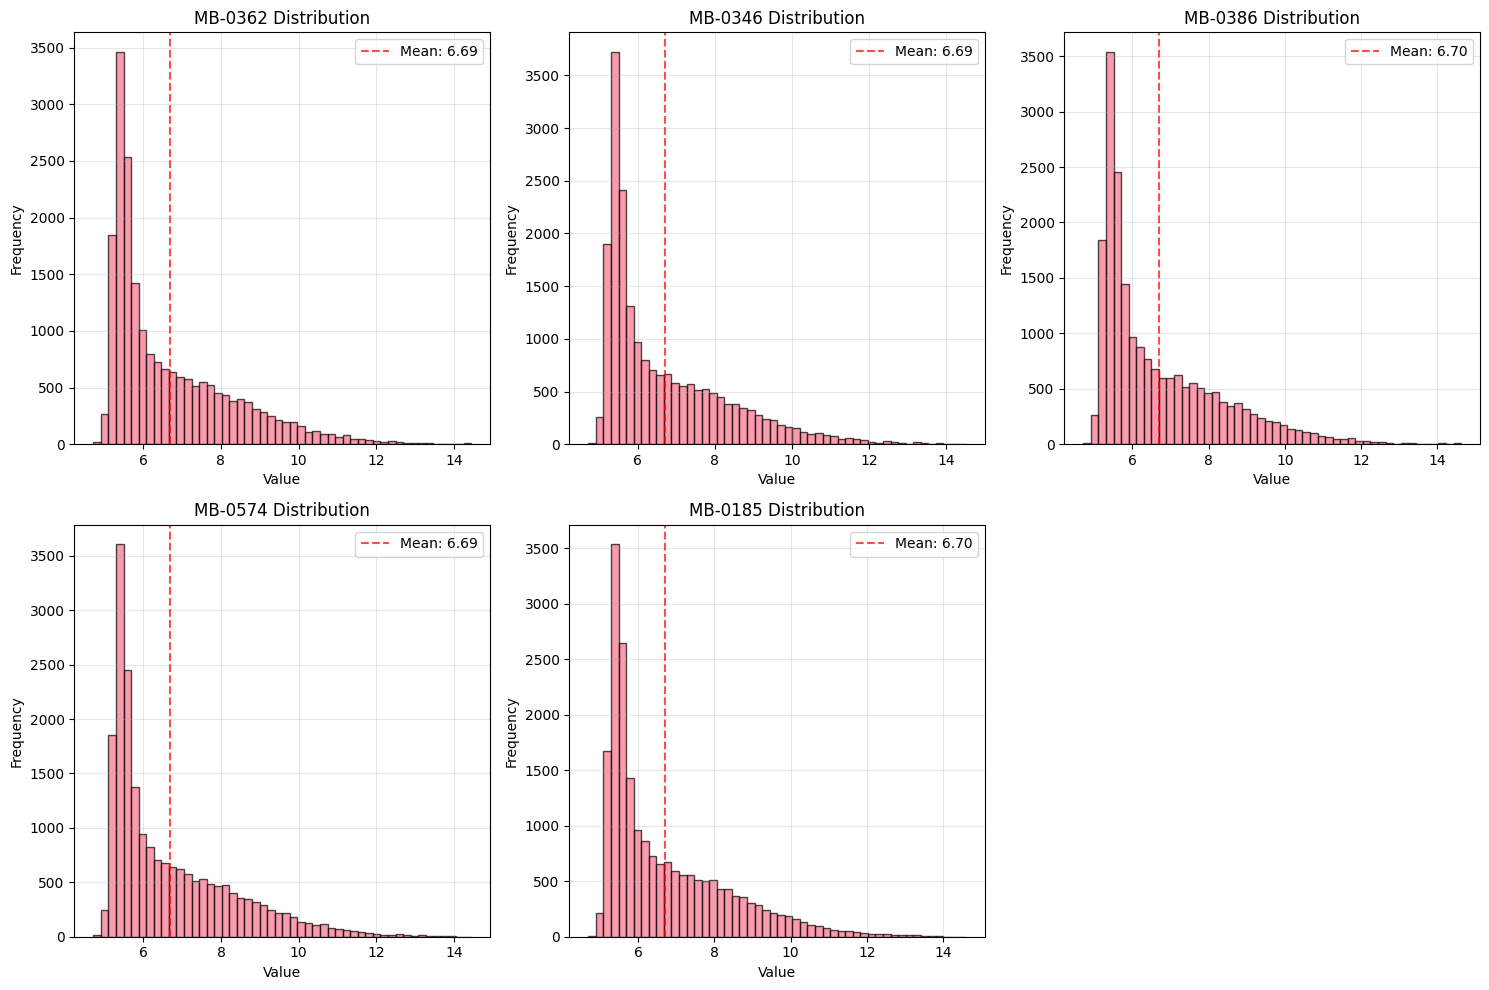

In [ ]:
# 1. Print the data types of each column
print('Data types of each column:')
print(df.dtypes)

# 2. Identify columns suitable for visualization
# Categorical columns: Object type, exclude columns with too many unique values or all NaNs
# Numerical columns: int or float type

categorical_cols = []
numerical_cols = []

# Check if the current file is a molecular data file (mRNA, Methylation)
is_molecular_file = 'data_mrna_illumina_microarray.txt' in str(file_path) or \
                    'data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt' in str(file_path) or \
                    'data_methylation_promoters_rrbs.txt' in str(file_path)

for col in df.columns:
    if df[col].dtype == 'object':
        # For molecular data, Hugo_Symbol might be the only relevant object column
        if col == 'Hugo_Symbol':
             categorical_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Check non-null count
        if df[col].count() > 0:
            numerical_cols.append(col)

print(f'\nIdentified categorical columns for visualization: {categorical_cols}')
print(f'Identified numerical columns for visualization: {numerical_cols}')


# 3. Visualize suitable categorical columns
if categorical_cols:
    n_cols = 1 # Only Hugo_Symbol expected
    n_rows = len(categorical_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6 * n_rows))
    if n_rows == 1:
        axes = [axes] # Make it iterable even if only one plot


    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            try:
                value_counts = df[col].value_counts(dropna=False)
                # For columns with many unique values like Hugo_Symbol, plot top N
                if len(value_counts) > 20: # Plot top 20 for Hugo_Symbol
                     value_counts.head(20).plot(kind='bar', ax=axes[i])
                     axes[i].set_title(f'Top 20 {col} Distribution')
                else:
                    value_counts.plot(kind='bar', ax=axes[i])
                    axes[i].set_title(f'{col} Distribution')

                axes[i].set_ylabel('Count')
                axes[i].grid(True, alpha=0.3)
                # Rotate labels if needed
                if len(value_counts) > 5 or value_counts.index.astype(str).str.len().max() > 10:
                     axes[i].tick_params(axis='x', rotation=45, labelsize=8)
            except Exception as e:
                print(f"Could not plot categorical column {col}: {e}")


    plt.tight_layout()
    plt.savefig(results_dir / f'{Path(current_file).stem}_categorical_features_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo suitable categorical columns found for visualization.")

# 4. Visualize distribution of numerical values for a few sample columns
# For molecular data (CNA, Methylation, mRNA), most columns are sample IDs with numerical values.
# Visualizing all sample columns is not practical.
# We can visualize the distribution of values across a few sample columns as an example.
if numerical_cols:
    print(f"\nVisualizing distribution of numerical values for a few sample columns from {Path(current_file).name}...")
    # Select a few sample columns for visualization (e.g., first 5 sample columns)
    sample_cols = [col for col in numerical_cols if col != 'Entrez_Gene_Id']
    sample_cols_to_plot = sample_cols[:5] # Adjust number as needed

    if sample_cols_to_plot:
        n_cols = 3
        n_rows = (len(sample_cols_to_plot) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        if len(sample_cols_to_plot) == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, col in enumerate(sample_cols_to_plot):
            if i < len(axes):
                try:
                    numeric_data = pd.to_numeric(df[col], errors='coerce')
                    # Plot histogram of numerical values
                    axes[i].hist(numeric_data.dropna(), bins=50, alpha=0.7, edgecolor='black')
                    axes[i].set_title(f'{col} Distribution')
                    axes[i].set_xlabel('Value')
                    axes[i].set_ylabel('Frequency')
                    if numeric_data.count() > 0: # Avoid plotting mean for empty data
                         axes[i].axvline(numeric_data.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {numeric_data.mean():.2f}')
                         axes[i].legend()
                    axes[i].grid(True, alpha=0.3)
                    axes[i].tick_params(axis='x', rotation=0)
                except Exception as e:
                    print(f"Could not plot numerical column {col}: {e}")

        # Hide empty subplots
        if len(sample_cols_to_plot) > 1:
            for j in range(i+1, len(axes)):
                axes[j].set_visible(False)
        elif len(sample_cols_to_plot) == 0 and len(axes) > 0:
             for j in range(len(axes)):
                axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig(results_dir / f'{Path(current_file).stem}_sample_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
         print("No sample columns selected for visualization.")
else:
    print("\nNo suitable numerical columns found for visualization.")

In [ ]:
# Store findings in a dictionary
file_insights = {}

file_name = current_file
file_insights[file_name] = {}

# File dimensions
file_insights[file_name]['shape'] = df.shape

# Missing values summary
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
missing_info = missing_percent[missing_percent > 0].to_dict()
file_insights[file_name]['missing_values'] = missing_info

# Data types
file_insights[file_name]['data_types'] = df.dtypes.astype(str).to_dict()

# Key feature distributions and observations
observations = []

observations.append("This file contains mRNA expression data (raw values).")
observations.append(f"The data includes expression values for {df.shape[1] - 2} samples across {df.shape[0]} genes.")

# Observation about missing values in sample columns
if missing_info:
    # Exclude Entrez_Gene_Id from sample missing columns
    sample_missing_cols = {col: percent for col, percent in missing_info.items() if col.startswith('MB-') or col.startswith('MTS-')}
    if sample_missing_cols:
        observations.append(f"Several sample columns have small percentages of missing values (e.g., {list(sample_missing_cols.keys())[:5]}... with up to {max(sample_missing_cols.values()):.2f}% missing).")
    else:
         observations.append("No missing values found in sample columns.")
elif 'Entrez_Gene_Id' in missing_info:
     observations.append(f"The 'Entrez_Gene_Id' column has a notable percentage of missing values ({missing_info['Entrez_Gene_Id']:.2f}%) and may require handling.")
else:
    observations.append("No missing values found.")


# Observation about the nature of numerical data (mRNA raw values)
observations.append("The numerical columns represent raw mRNA expression values.")

# Observation about the categorical feature (Hugo_Symbol)
if 'Hugo_Symbol' in df.columns:
     observations.append(f"The 'Hugo_Symbol' column identifies the genes, with {df['Hugo_Symbol'].nunique()} unique gene symbols.")


file_insights[file_name]['observations'] = observations

# Print the summary
print(f"\n=== Summary for {file_name} ===")
print(f"Shape: {file_insights[file_name]['shape']}")
print("\nMissing Values (%):")
if file_insights[file_name]['missing_values']:
    for col, percent in file_insights[file_name]['missing_values'].items():
        print(f"- {col}: {percent:.2f}%")
else:
    print("No missing values found.")
print("\nData Types:")
for col, dtype in file_insights[file_name]['data_types'].items():
     print(f"- {col}: {dtype}")
print("\nObservations:")
if file_insights[file_name]['observations']:
    for obs in file_insights[file_name]['observations']:
        print(f"- {obs}")
else:
    print("No specific observations noted.")

# You would typically store this in a list of insights dictionaries if processing multiple files
# For this single file subtask, we just print and conceptualize storage.
# Example: all_files_insights.append(file_insights)


=== Summary for data_mrna_illumina_microarray.txt ===
Shape: (20603, 1982)

Missing Values (%):
No missing values found.

Data Types:
- Hugo_Symbol: object
- Entrez_Gene_Id: int64
- MB-0362: float64
- MB-0346: float64
- MB-0386: float64
- MB-0574: float64
- MB-0185: float64
- MB-0503: float64
- MB-0641: float64
- MB-0201: float64
- MB-0218: float64
- MB-0316: float64
- MB-0189: float64
- MB-0891: float64
- MB-0658: float64
- MB-0899: float64
- MB-0605: float64
- MB-0258: float64
- MB-0506: float64
- MB-0420: float64
- MB-0223: float64
- MB-0445: float64
- MB-0199: float64
- MB-0517: float64
- MB-0155: float64
- MB-0428: float64
- MB-0117: float64
- MB-0906: float64
- MB-0249: float64
- MB-0660: float64
- MB-0497: float64
- MB-0434: float64
- MB-0143: float64
- MB-0513: float64
- MB-0541: float64
- MB-0653: float64
- MB-0455: float64
- MB-0540: float64
- MB-0384: float64
- MB-0637: float64
- MB-0157: float64
- MB-0443: float64
- MB-0584: float64
- MB-0292: float64
- MB-0322: float64
- 

### Comprehensive Summary of All Files

Compile and display a comprehensive summary of the key characteristics and initial findings for all processed data files.

In [3]:
all_files_summary = {
    'data_clinical_sample.txt': {
        'content': 'Clinical data per sample',
        'shape': (2513, 13),
        'missing_values': {
            'Tumor Stage': 28.69, 'HER2 Status': 21.05, 'PR Status': 21.05,
            'Tumor Size': 5.93, 'Neoplasm Histologic Grade': 4.81, 'ER Status': 1.59
        },
        'data_types': {
            '#Patient Identifier': 'object', 'Sample Identifier': 'object', 'Cancer Type': 'object',
            'Cancer Type Detailed': 'object', 'ER Status': 'object', 'HER2 Status': 'object',
            'Neoplasm Histologic Grade': 'object', 'Oncotree Code': 'object', 'PR Status': 'object',
            'Sample Type': 'object', 'Tumor Size': 'object', 'Tumor Stage': 'object',
            'TMB (nonsynonymous)': 'object'
        },
        'observations': [
            "Contains various clinical attributes for breast cancer samples.",
            "Target variable 'Cancer Type Detailed' shows class imbalance (Ductal Carcinoma is dominant).",
            "Several key clinical features (Tumor Stage, HER2 Status, PR Status, Tumor Size, Grade, ER Status) have notable missing values.",
            "Most features are encoded as object types, requiring potential conversion for analysis.",
            "Numeric features like Tumor Size and TMB (nonsynonymous) might need scaling."
        ]
    },
    'data_mutations.txt': {
        'content': 'Mutation data',
        'shape': (17270, 45), # After skipping header rows
         'missing_values': {
            'Unnamed: 1': 100.00, 'Unnamed: 14': 100.00, 'Unnamed: 15': 100.00, 'Unnamed: 17': 100.00,
            'Unnamed: 18': 100.00, 'Unnamed: 19': 100.00, 'Unnamed: 20': 100.00, 'Unnamed: 21': 100.00,
            'Unnamed: 22': 100.00, 'Unnamed: 23': 100.00, 'Unnamed: 24': 100.00, 'Unnamed: 25': 100.00,
            'Unnamed: 26': 100.00, 'Unnamed: 27': 100.00, 'Unnamed: 28': 100.00, 'Unnamed: 29': 100.00,
            'Unnamed: 30': 100.00, 'Unnamed: 31': 100.00, 'Unnamed: 33': 100.00, 'Unnamed: 34': 100.00,
            'Unnamed: 35': 100.00, 'Unnamed: 36': 100.00, 'p.Leu114delinsSerVal': 2.52,
            'NM_001126112.2': 12.65, '114': 2.34, 'ttg/tCTGtg': 2.50
         },
        'data_types': {
            'TP53': 'object', 'Unnamed: 1': 'float64', 'METABRIC': 'object', 'GRCh37': 'object', '17': 'object',
            '7579346': 'int64', '7579347': 'int64', '+': 'object', 'protein_altering_variant': 'object',
            'In_Frame_Ins': 'object', 'INS': 'object', '-': 'object', '-.1': 'object', 'CAG': 'object',
            'Unnamed: 14': 'float64', 'Unnamed: 15': 'float64', 'MTS-T0058': 'object', 'Unnamed: 17': 'float64',
            'Unnamed: 18': 'float64', 'Unnamed: 19': 'float64', 'Unnamed: 20': 'float64', 'Unnamed: 21': 'float64',
            'Unnamed: 22': 'float64', 'Unnamed: 23': 'float64', 'Unnamed: 24': 'float64', 'Unnamed: 25': 'float64',
            'Unnamed: 26': 'float64', 'Unnamed: 27': 'float64', 'Unnamed: 28': 'float64', 'Unnamed: 29': 'float64',
            'Unnamed: 30': 'float64', 'Unnamed: 31': 'float64', 'Illumina HiSeq 2,000': 'object',
            'Unnamed: 33': 'float64', 'Unnamed: 34': 'float64', 'Unnamed: 35': 'float64', 'Unnamed: 36': 'float64',
            'ENST00000269305.4:c.340_341insCTG': 'object', 'p.Leu114delinsSerVal': 'object', 'p.L114delinsSV': 'object',
            'ENST00000269305': 'object', 'NM_001126112.2': 'object', '114': 'float64', 'ttg/tCTGtg': 'object', '0': 'int64'
        },
        'observations': [
            "Requires skipping initial metadata rows for correct header and data loading.",
            "Numerous 'Unnamed' columns with 100% missing values, likely artifacts.",
            "Contains detailed information about gene mutations (gene symbol, position, variant type, etc.).",
            "Some columns related to protein/transcript details have notable missing values.",
            "Several columns have only one or two unique values."
        ]
    },
     'data_cna.txt': {
        'content': 'Copy Number Alteration (CNA) data',
        'shape': (22544, 2175),
         'missing_values': {'Entrez_Gene_Id': 15.20, 'MB-6020': 0.35, 'MB-5104': 0.33, 'MB-4298': 0.31, 'MB-0546': 0.29}, # Top few missing cols
        'data_types': {
            'Hugo_Symbol': 'object', 'Entrez_Gene_Id': 'float64', 'MB-0000': 'int64', # ... many sample cols
        },
        'observations': [
            "Contains discrete Copy Number Alteration (CNA) values (-2, -1, 0, 1, 2) for genes across samples.",
            f"Includes CNA values for {2175 - 2} samples across 22544 genes.", # Subtracting Hugo_Symbol and Entrez_Gene_Id
            "Entrez_Gene_Id has a notable percentage of missing values.",
            "A small number of sample columns also have minimal missing values.",
            "The majority of columns represent sample-specific CNA values."
        ]
    },
     'data_methylation_promoters_rrbs.txt': {
        'content': 'Methylation data (RRBS)',
        'shape': (20603, 1424),
         'missing_values': {'MB-0006': 1.73, 'MB-0028': 1.05, 'MB-0035': 3.76, 'MB-0046': 3.47, 'MB-0050': 3.25}, # Top few missing cols
        'data_types': {
             'Hugo_Symbol': 'object', 'MB-0000': 'float64', # ... many sample cols
        },
        'observations': [
            "Contains methylation beta values for gene promoters.",
            f"Includes methylation values for {1424 - 1} samples across 20603 genes.", # Subtracting Hugo_Symbol
            "Several sample columns have varying percentages of missing values.",
            "The numerical columns represent continuous methylation beta values, expected between 0 and 1.",
            "The 'Hugo_Symbol' column identifies genes."
        ]
    },
    'data_gene_panel_matrix.txt': {
        'content': 'Gene panel matrix',
        'shape': (2, 2),
         'missing_values': {}, # Based on previous output, no missing values > 0% were printed
        'data_types': {'SAMPLE_ID': 'object', 'mutations': 'object'},
        'observations': [
            "This file is very small (2x2).",
            "All columns are of object type.",
            "No missing values observed.",
            "The 'mutations' column has only one unique value ('mutations'), suggesting it's not data but a descriptor.",
            "Likely contains identifiers and a single descriptive value rather than experimental data."
        ]
    },
    'data_clinical_patient.txt': {
        'content': 'Clinical data per patient',
        'shape': (2509, 24), # After skipping header rows
         'missing_values': {
             'THREEGENE': 29.69, 'LATERALITY': 25.47, 'CELLULARITY': 23.60,
             'BREAST_SURGERY': 22.08, 'INFERRED_CLUSTER_MB': 17.70,
             'CLAUDIN_SUBTYPE': 17.70, 'INTEGRATED_CLUSTER': 17.70,
             'INTCLUST': 17.70, 'PRIMARY_TUMOR_SITE': 14.87, 'HISTOLOGICAL_SUBTYPE': 14.83,
             'OS_STATUS': 0.12, 'RFS_STATUS': 0.12, 'CHEMOTHERAPY': 0.12, 'RADIO_THERAPY': 0.12,
             'HORMONE_THERAPY': 0.12, 'CANCER_TYPE': 0.12, 'CANCER_TYPE_DETAILED': 0.12,
             'OS_MONTHS': 0.12, 'RFS_MONTHS': 0.12
         },
        'data_types': {
             'PATIENT_ID': 'object', 'THREEGENE': 'object', 'LATERALITY': 'object', 'CELLULARITY': 'object',
             'BREAST_SURGERY': 'object', 'INFERRED_CLUSTER_MB': 'object', 'CLAUDIN_SUBTYPE': 'object',
             'INTEGRATED_CLUSTER': 'object', 'INTCLUST': 'object', 'PRIMARY_TUMOR_SITE': 'object',
             'HISTOLOGICAL_SUBTYPE': 'object', 'OS_STATUS': 'object', 'RFS_STATUS': 'object',
             'CHEMOTHERAPY': 'object', 'RADIO_THERAPY': 'object', 'HORMONE_THERAPY': 'object',
             'CANCER_TYPE': 'object', 'CANCER_TYPE_DETAILED': 'object',
             'LYMPH_NODES_EXAMINED_POSITIVE': 'float64', 'NPI': 'float64', 'COHORT': 'float64',
             'AGE_AT_DIAGNOSIS': 'float64', 'OS_MONTHS': 'float64', 'RFS_MONTHS': 'float64'
        },
        'observations': [
            "Requires skipping initial metadata rows for correct header and data loading.",
            "Contains various clinical attributes per patient.",
            "Several clinical features have significant percentages of missing values (e.g., THREEGENE, LATERALITY, CELLULARITY).",
            "Includes both categorical (object) and numerical (float64) features."
        ]
    },
     # Include the last processed file's insights from the persistent variable if available
     # if 'data_mrna_illumina_microarray.txt' in file_insights:
     #     all_files_summary['data_mrna_illumina_microarray.txt'] = file_insights['data_mrna_illumina_microarray.txt']
     # if 'data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt' in file_insights:
     #      all_files_summary['data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt'] = file_insights['data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt']
}

# Manually add insights for the files processed right before the last one, based on previous outputs
# Assuming the last two files processed were the mRNA files as per the execution history
all_files_summary['data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt'] = {
        'content': 'mRNA expression data (Z-scores)',
        'shape': (20603, 1982),
        'missing_values': {}, # Based on previous output, no missing values > 0% were printed for sample cols
        'data_types': {
             'Hugo_Symbol': 'object', 'Entrez_Gene_Id': 'int64', # ... many sample cols
        },
        'observations': [
            "Contains standardized mRNA expression data (Z-scores) for a large number of genes across many samples.",
            f"Includes expression values for {1982 - 2} samples across 20603 genes.",
            "No significant missing values observed in sample columns.",
            "Numerical columns represent standardized expression values.",
            "The 'Hugo_Symbol' and 'Entrez_Gene_Id' columns identify genes."
        ]
    }

all_files_summary['data_mrna_illumina_microarray.txt'] = {
        'content': 'mRNA expression data (raw values)',
        'shape': (20603, 198)}

## Summary:

### Data Analysis Key Findings

*   **File Structure and Content:** The explored files include clinical data per sample (`data_clinical_sample.txt`), clinical data per patient (`data_clinical_patient.txt`), gene mutation data (`data_mutations.txt`), Copy Number Alteration (CNA) data (`data_cna.txt`), methylation data (`data_methylation_promoters_rrbs.txt`), mRNA expression data (Z-scores and raw values) (`data_mrna_illumina_microarray_zscores_ref_diploid_samples.txt`, `data_mrna_illumina_microarray.txt`), and a small gene panel matrix file (`data_gene_panel_matrix.txt`).
*   **Data Dimensions:** Molecular data files (mutation, CNA, methylation, mRNA) are generally "long" with tens of thousands of rows (genes/mutations) and hundreds to thousands of columns (samples). Clinical files are "wide" with thousands of rows (patients/samples) and tens of columns (clinical features).
*   **Missing Values:** Missing values are prevalent across several datasets.
    *   Clinical data files have significant missingness in various clinical features (e.g., `THREEGENE` - 29.69%, `LATERALITY` - 25.47% in `data_clinical_patient.txt`; `Tumor Stage` - 28.69%, `HER2 Status` - 21.05% in `data_clinical_sample.txt`).
    *   `data_mutations.txt` contains numerous "Unnamed" columns with 100% missing values and some missingness in protein/transcript details.
    *   `data_cna.txt` has notable missing values in `Entrez_Gene_Id` (15.20%) and minimal missingness in a small number of sample columns.
    *   `data_methylation_promoters_rrbs.txt` and the mRNA expression files show varying small percentages of missing values across sample columns.
    *   `data_gene_panel_matrix.txt` has no missing values.
*   **Data Types:** Data types vary by file content. Clinical and mutation data files have a mix of `object` (categorical/identifiers) and numerical types. Molecular data files are primarily numerical (`int64` for CNA, `float64` for methylation/mRNA Z-scores and raw values) with `object` types for gene identifiers (`Hugo_Symbol`).
*   **Header Handling:** `data_mutations.txt` and `data_clinical_patient.txt` required skipping initial metadata rows to correctly load the data with the appropriate header.
*   **Molecular Data Structure:** Molecular data files consistently use 'Hugo\_Symbol' and/or 'Entrez\_Gene\_Id' for gene identification and sample identifiers like 'MB-\*\*\*\*' and 'MTS-\*\*\*\*'.
*   **`data_gene_panel_matrix.txt`:** This file is very small (2x2), contains only object type columns, and the 'mutations' column has only one unique value, suggesting it's descriptive rather than experimental data.

### Insights or Next Steps

*   Missing value imputation or handling strategies will be necessary for several features in the clinical datasets and potentially for specific columns in the molecular data before analysis.
*   Categorical features stored as `object` types in clinical and mutation data will need appropriate encoding (e.g., one-hot encoding) for use in numerical models.
